In [1]:
import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss, confusion_matrix 
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import classification_report
import statsmodels.api as sm
import sys
import shap
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, optimal_threashold_fbeta_scalar, plot_imbalance, dataframe_describe
from utils import plot_roc_curve, plot_pr_curve, plot_probability_curve, binary_entropy
import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
P = 'P1'
p = P.lower()

file1 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\CMacedonia\GR_CMacedonia_WNV_Dataset_OP_2010_2023.csv'
file2 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\Thessaly\GR_Thessaly_WNV_Dataset_OP_2010_2023.csv'
file3 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\Thrace\GR_Thrace_WNV_Dataset_OP_2010_2023.csv'
file4 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\Attica\GR_Attica_WNV_Dataset_OP_2010_2023.csv'
file5 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\Peloponnese\GR_Peloponnese_WNV_Dataset_OP_2010_2023.csv'

dataset1 = read_data(file1)
dataset2 = read_data(file2)
dataset3 = read_data(file3)
dataset4 = read_data(file4)
dataset5 = read_data(file5)


dataset1.head()

dataset2.head()

dataset3.head()

dataset4.head()

dataset5.head()

dataset = pd.concat([dataset1, 
                     dataset2, 
                     dataset3, 
                     dataset4, 
                     dataset5,
                     ])

dataset.reset_index(drop = True, inplace = True)

print(dataset.shape)

(4200, 112)


In [2]:
dataset

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL521,2010,1,22.217953,40.552111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.230096,5.166060,9.054669,14.068100,14.068100,2.490562,0.057874,0.608776,1.209346,1.209346,6.360329,2.696421,4.831723,7.638723,7.638723,0.104074,15.201481,9.578581,51.883864,98.485803,288.402406,1461.841477,31.000000,1.000000,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,31,36,30,12,12,1,6,7,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,4287.0,4163.0,0
1,EL522,2010,1,23.139033,40.693632,0.240287,0.059537,-0.141941,-0.059537,0.215547,0.069956,-0.106000,-0.069956,0.049703,0.064085,0.084328,0.064085,11.844360,7.145869,9.818153,15.604511,15.604511,2.833916,-0.061709,0.147210,1.468130,1.468130,7.339138,3.542080,4.982681,8.536321,8.536321,0.190938,15.922969,9.407951,37.402003,76.781372,290.599935,1330.804946,31.000000,1.000000,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,31,30,30,10,10,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.0,1.0,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,13373.0,15210.0,0
2,EL523,2010,1,22.762317,41.016275,0.270784,-0.039708,-0.307282,0.039708,0.264906,-0.037696,-0.294932,0.037696,0.050738,0.048113,0.097949,0.048113,10.279993,7.289129,9.855217,16.110757,16.110757,2.501269,-1.712222,-0.396863,0.873001,0.873001,6.390631,2.788454,4.729177,8.491879,8.491879,-1.350000,17.236087,9.239469,47.729387,98.428751,284.920463,1386.197739,31.000000,1.000000,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.0,1.0,22771.829003,3753.170334,32,324.927224,972

In [3]:
len(dataset.NUTS3_ID.unique())

25

In [4]:
dataset = encode_cyclical(dataset, 'month', 12)

In [5]:
dataset.cases.sum()

1768

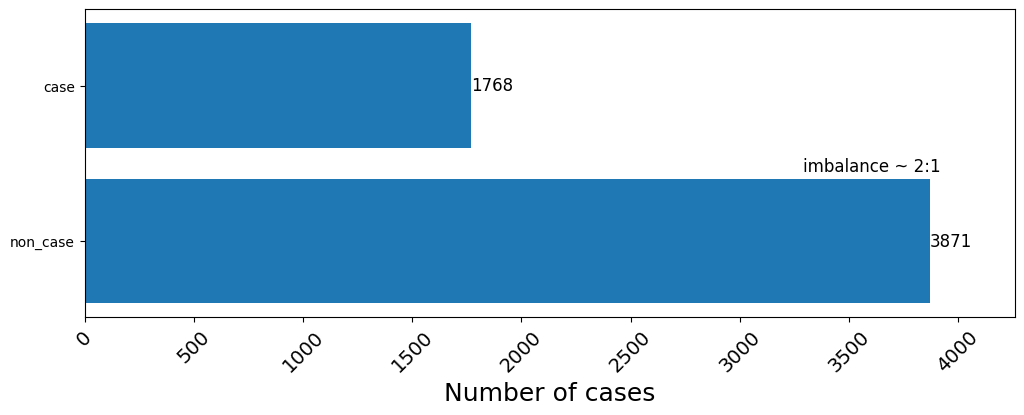

In [6]:
plot_imbalance(dataset, target_column='cases')

In [7]:
#dataset = dataset.query('month >= 5 & month <= 11')
dataset = dataset.query('month >= 5 & month <= 10 & year <= 2021')
# dataset = dataset.query('month >= 5')
dataset.reset_index(drop=True, inplace=True)

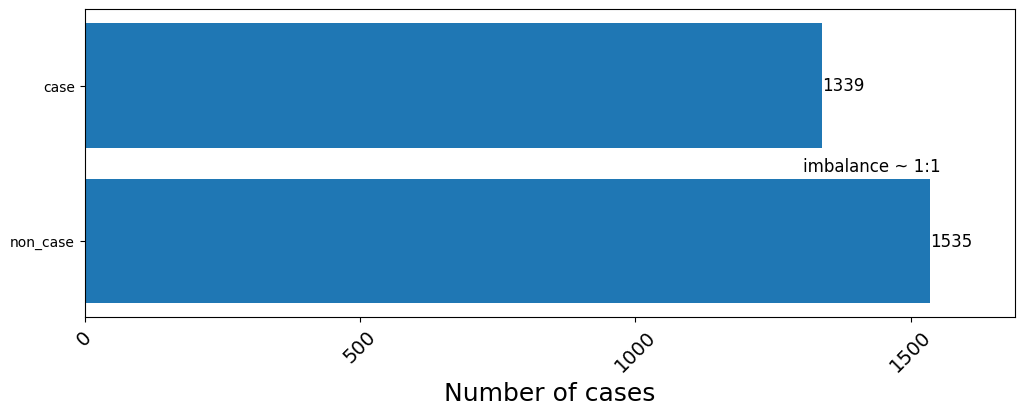

In [8]:
plot_imbalance(dataset, target_column='cases')

In [9]:
dataset.shape

(1800, 114)

In [10]:
dataset.cases.sum()

1339

In [11]:
dsc = dataframe_describe(dataset, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,126,260,386,0.48%
1,2011,118,91,209,1.30%
2,2012,124,141,265,0.88%
3,2013,126,83,209,1.52%
4,2014,145,13,158,11.15%
5,2015,150,0,150,inf%
6,2016,150,0,150,inf%
7,2017,145,41,186,3.54%
8,2018,97,295,392,0.33%
9,2019,109,221,330,0.49%


In [12]:
X = dataset.select_dtypes(exclude=['object']).drop(columns=['cases'])
y = dataset['cases']

#features_to_remove = ['x', 'y', 'year', 'month', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_min', 'distance_to_river_min', 'slope_mean_1km_min', 'aspect_mean_200m_min', 'elevation_mean_1km_min', 'hillshade_mean_1km_min', 'fs_area_1km_min', 'flow_accu_200m_min', 'distance_to_coast_max', 'distance_to_river_max', 'slope_mean_1km_max', 'aspect_mean_200m_max', 'elevation_mean_1km_max', 'hillshade_mean_1km_max', 'fs_area_1km_max', 'flow_accu_200m_max', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std']
features_to_remove = ['year', 'month', 'distance_to_coast_min', 'distance_to_river_min', 'slope_mean_1km_min', 'aspect_mean_200m_min', 'elevation_mean_1km_min', 'hillshade_mean_1km_min', 'fs_area_1km_min', 'flow_accu_200m_min', 
                      'distance_to_coast_max', 'distance_to_river_max', 'slope_mean_1km_max', 'aspect_mean_200m_max', 'elevation_mean_1km_max', 'hillshade_mean_1km_max', 'fs_area_1km_max', 'flow_accu_200m_max']
#features_to_remove = features_to_remove + ['ndbi', 'ndbi_std', 'females_total', 'females_15t64']
#features_to_remove = ['year', 'month']
feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['x', 'y', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc', 'mosq_pred_mean', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_

In [13]:
dataset['nuts2_id'] = dataset['NUTS3_ID'].str[:4]

In [14]:
dataset

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases,month_sin,month_cos,nuts2_id
0,EL521,2010,5,22.217953,40.552111,0.408398,0.144143,-0.235554,-0.144143,0.412976,0.140501,-0.242655,-0.140501,0.044047,0.046857,0.041740,0.046857,22.445667,6.180824,6.775942,16.031804,22.445667,7.345457,2.721929,1.588987,3.674767,7.345457,14.895562,4.451377,4.182464,9.853286,14.895562,4.901481,27.258519,2.472640,8.438265,56.295983,74.179192,558.574506,744.314815,24.810494,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,31,36,30,12,12,1,6,7,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,4287.0,4163.0,0,0.500000,-8.660254e-01,EL52
1,EL522,2010,5,23.139033,40.693632,0.417461,0.158374,-0.240587,-0.158374,0.404465,0.156728,-0.228864,-0.156728,0.043854,0.042760,0.033155,0.042760,22.021724,7.924345,8.919715,16.838180,22.021724,8.176359,1.718196,2.592662,4.207480,8.176359,15.099042,4.821270,5.756189,10.522830,15.099042,6.827969,27.816719,2.203142,14.748729,43.918049,66.094267,462.422352,670.359375,22.345312,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,31,30,30,10,10,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.0,1.0,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,13373.0,15210.0,0,0.500000,-8.660254e-01,EL52
2,EL523,2010,5,22.762317,41.016275,0.392183,0.130465,-0.244458,-0.130465,0.412952,0.161777,-0.227281,-0.161777,0.037472,0.039575,0.034869,0.039575,22.303014,7.171515,8.296955,17.445933,22.303014,7.777080,0.395722,2.653680,3.611627,7.777080,15.040047,3.783619,5.475318,10.528780,15.040047,6.112391,27.085435,2.711588,17.818245,55.373941,81.347629,421.128773,742.434783,24.747826,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.

In [15]:
print(f"Total Features Used: {len(feature_names)}")

Total Features Used: 94


In [16]:
print(feature_names)

Index(['x', 'y', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean',
       'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean',
       'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max',
       'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc',
       'mosq_pred_mean', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6',
       'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14',
       'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_prop1', 'lc_prop2',
       'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',
       'distance_to_coast', 'distance_to_river', 'slope

In [17]:
weights = pd.Series(y.clip(lower=1).values, name = 'weights')

weights_new = np.ceil(weights / 2).astype(int)

In [18]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []

nuts2_ids = ['EL30', 'EL51', 'EL52']

for nuts2 in nuts2_ids:
    train_idx = dataset.index[dataset["nuts2_id"] != nuts2].tolist()
    test_idx = dataset.index[dataset["nuts2_id"] == nuts2].tolist()

    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    weights_train = weights.iloc[train_idx]

    print(f"Train: {data_train['nuts2_id'].unique()} | Test: {data_test['nuts2_id'].unique()}")
    print(f"Train size: {len(train_idx)} | Test size: {len(test_idx)}")

    data_train['cases'] = data_train['cases'].apply(lambda x: 1 if x > 0 else 0)
    data_test['cases'] = data_test['cases'].apply(lambda x: 1 if x > 0 else 0)

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    sum_negatives = data_train['cases'].value_counts().get(0)
    sum_positives = data_train['cases'].value_counts().get(1)

    params = {
             "objective": "binary:logistic", #default "binary:logistic"
             "device": "gpu", #default "cpu"
             "eval_metric": "logloss", #default "logloss"
             "learning_rate": 0.03, #default 0.1
             "n_estimators": 400, #default 100
             "subsample": 0.8, #default 1.0
             "colsample_bytree": 0.8, #default 1.0
             "max_depth": 6, #default 6
             "min_child_weight": 1, #default 1
             "gamma": 0, #default 0 
             "reg_alpha": 0, #default 0
             "reg_lambda": 1.0, #default 1.0
             "max_delta_step": 0, #default 0
            #"scale_pos_weight": sum_negatives / sum_positives,
        }



    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])

    y_train = data_train['cases']
    y_test = data_test['cases']

    print(f"Training set 0/1 Ratio: {(data_train['cases'].value_counts().get(0) / data_train['cases'].value_counts().get(1)):.2f}")
    print(f"Test set 0/1 Ratio: {(data_test['cases'].value_counts().get(0) / data_test['cases'].value_counts().get(1)):.2f}")
    print(f"Weight: {(sum_negatives/sum_positives):.2f}")
            
    imputer = SimpleImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train)
    X_test_imputed = imputer.transform(X_test)

    model = xgb.XGBClassifier(**params)  

    calibrated_model = CalibratedClassifierCV(model,method="isotonic",cv=3)

    trained_model = calibrated_model.fit(X_train_imputed, y_train, sample_weight = weights_train)

    y_train_prob = trained_model.predict_proba(X_train_imputed)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    y_train_list.append(y_train)
    y_test_list.append(y_test)
    y_train_prob_list.append(y_train_prob)
    y_test_prob_list.append(y_test_prob)
    fold_counter += 1

Train: ['EL52' 'EL61' 'EL51' 'EL65'] | Test: ['EL30']
Train size: 1296 | Test size: 504
Training set 0/1 Ratio: 5.55
Test set 0/1 Ratio: 6.52
Weight: 5.55
Train: ['EL52' 'EL61' 'EL30' 'EL65'] | Test: ['EL51']
Train size: 1440 | Test size: 360
Training set 0/1 Ratio: 5.73
Test set 0/1 Ratio: 6.06
Weight: 5.73
Train: ['EL61' 'EL51' 'EL30' 'EL65'] | Test: ['EL52']
Train size: 1296 | Test size: 504
Training set 0/1 Ratio: 7.76
Test set 0/1 Ratio: 3.31
Weight: 7.76


In [19]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)


df_test = pd.DataFrame({'score': y_test_proba[:, 1], 'target': y_test_true})

In [20]:
train_loss = log_loss(y_train_true, y_train_proba[:, 1])
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss(y_test_true, y_test_proba[:, 1])
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 0.3017
Test Loss: 0.4739


In [21]:
classification_thresholds = optimal_threashold_fbeta_scalar(y_test_proba[:,1], y_test_true, beta = 1, round_factor = 2)
print(classification_thresholds)
thr = classification_thresholds

0.34


In [22]:
y_train_pred = np.where(y_train_proba[:,1] > thr, 1, 0)
y_test_pred = np.where(y_test_proba[:,1] > thr, 1, 0)


print(classification_report(y_test_true, y_test_pred, output_dict=False))

              precision    recall  f1-score   support

           0       0.90      0.68      0.78      1133
           1       0.30      0.65      0.41       235

    accuracy                           0.67      1368
   macro avg       0.60      0.66      0.59      1368
weighted avg       0.80      0.67      0.71      1368



In [23]:
brier = brier_score_loss(y_test_true, y_test_proba[:,1])

print("Brier score:", brier)

Brier score: 0.15149036830468565


In [24]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''


cm = confusion_matrix(y_test_true, y_test_pred)

print(cm)

[[769 364]
 [ 82 153]]


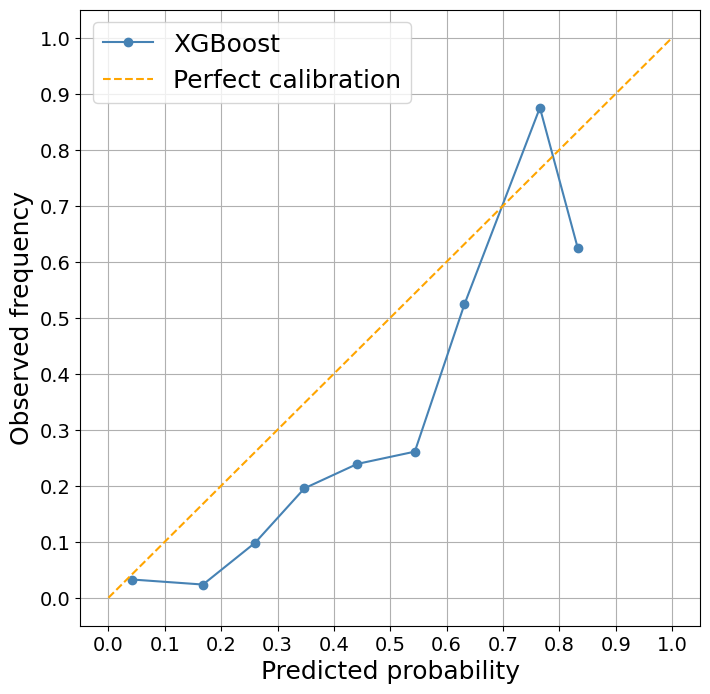

In [25]:
tick_size = 14
label_size = 18
legend_size = 18
text_size = 18

prob_true, prob_pred = calibration_curve(
    y_test_true,
    y_test_proba[:,1],
    n_bins=10,
    strategy="uniform"
)

plt.subplots(1, figsize=(8,8))

plt.plot(prob_pred, prob_true, marker="o", color = 'steelblue', label="XGBoost")
plt.plot([0,1], [0,1], linestyle="--", color = 'orange', label="Perfect calibration")

plt.xlabel("Predicted probability", size=label_size)
plt.ylabel("Observed frequency", size=label_size)
plt.yticks(np.arange(0, 1.1, step = 0.1), size=tick_size)
plt.xticks(np.arange(0, 1.1, step = 0.1), size=tick_size)
plt.legend(prop={'size': legend_size})
plt.grid(True)
plt.show()

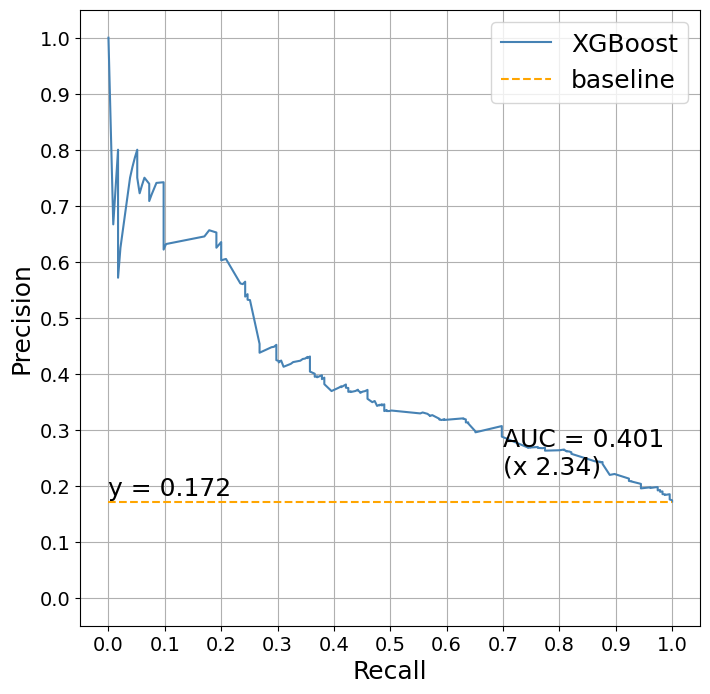

(0.6979, 0.31, 0.426, 0.34)

In [26]:
plot_pr_curve(df_test, target_col = 'target', model_name='XGBoost', plot_fbeta=False, beta = 1)

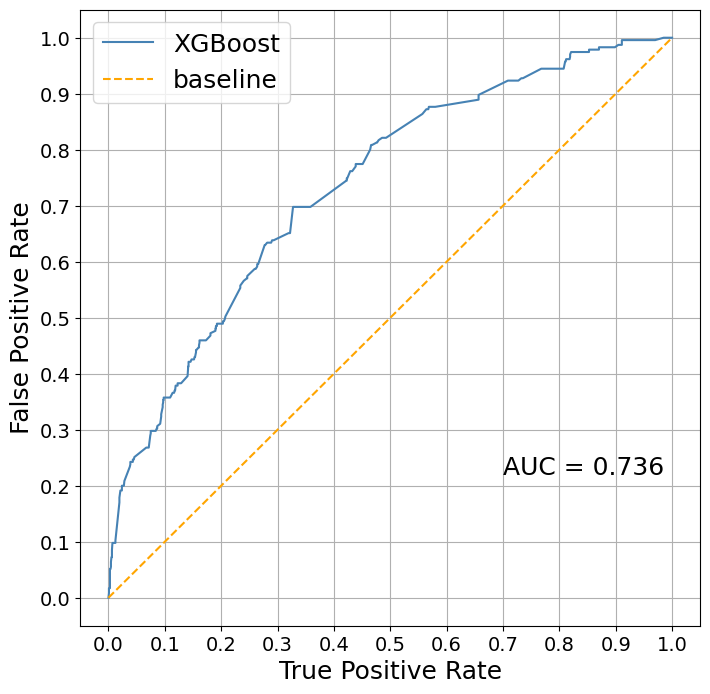

(0.3274, 0.6979, 0.6851, 0.3369)

In [27]:
plot_roc_curve(df_test, target_col = 'target', model_name='XGBoost')

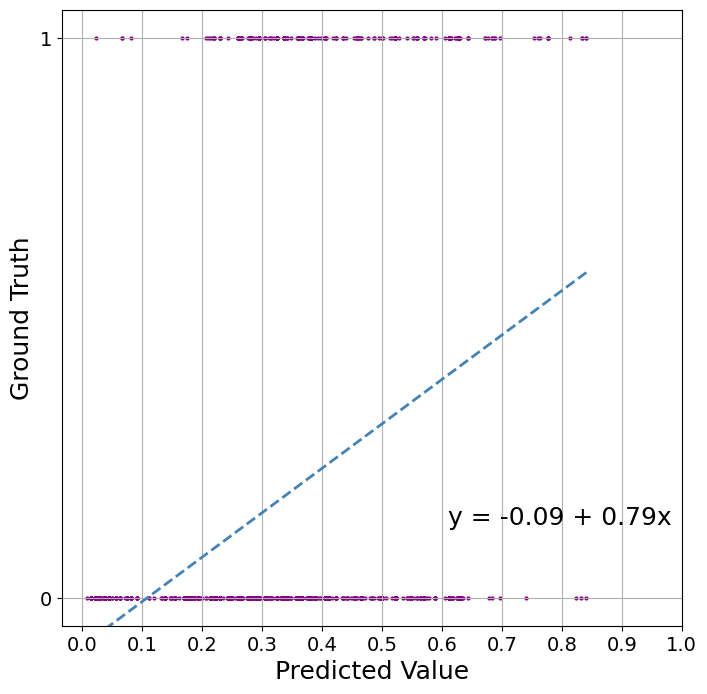

(-0.08628476210811285, 0.7932847092883112)

In [28]:
plot_probability_curve(df_test, target_col = 'target', marker_size=4, x_label = 'Predicted Value', marker_shape='o')

In [29]:
n_ensembles = 10
n_folds = 10

# Store all predictions and ground truth
all_y_test = []
all_y_test_prob = []
all_test_indices = []

nuts2_ids = ['EL30', 'EL51', 'EL52']

# Ensemble loop
for ensemble_id in range(n_ensembles):
    print(f"\n=== Ensemble {ensemble_id + 1}/{n_ensembles} ===\n")

    nuts2_ids = ['EL30', 'EL51', 'EL52']

    for nuts2 in nuts2_ids:
        train_idx = dataset.index[dataset["nuts2_id"] != nuts2].tolist()
        test_idx = dataset.index[dataset["nuts2_id"] == nuts2].tolist()

        data_train = dataset.iloc[train_idx]
        data_test = dataset.iloc[test_idx]
        weights_train = weights.iloc[train_idx]

        print(f"Train: {data_train['nuts2_id'].unique()} | Test: {data_test['nuts2_id'].unique()}")
        print(f"Train size: {len(train_idx)} | Test size: {len(test_idx)}")

        data_train['cases'] = data_train['cases'].apply(lambda x: 1 if x > 0 else 0)
        data_test['cases'] = data_test['cases'].apply(lambda x: 1 if x > 0 else 0)

        data_train.reset_index(inplace = True, drop = True)
        data_test.reset_index(inplace = True, drop = True)

        sum_negatives = data_train['cases'].value_counts().get(0)
        sum_positives = data_train['cases'].value_counts().get(1)

        params = {
            "seed": ensemble_id * 100 + fold_counter,  # unique seed per model
            "objective": "binary:logistic", #default "binary:logistic"
             "device": "gpu", #default "cpu"
             "eval_metric": "logloss", #default "logloss"
             "learning_rate": 0.03, #default 0.1
             "n_estimators": 400, #default 100
             "subsample": 0.8, #default 1.0
             "colsample_bytree": 0.8, #default 1.0
             "max_depth": 6, #default 6
             "min_child_weight": 1, #default 1
             "gamma": 0, #default 0 
             "reg_alpha": 0, #default 0
             "reg_lambda": 1.0, #default 1.0
             "max_delta_step": 0, #default 0
            #"scale_pos_weight": sum_negatives / sum_positives,
        }

        X_train = data_train.select_dtypes(exclude=['object']).drop(columns=features_to_remove + ['cases'])
        X_test = data_test.select_dtypes(exclude=['object']).drop(columns=features_to_remove + ['cases'])

        y_train = data_train['cases']
        y_test = data_test['cases']

        scaler = MinMaxScaler(feature_range=(-1, 1))
        scaler.fit(X_train)
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        imputer = KNNImputer()
        imputer.fit(X_train_scaled)
        X_train_imputed = imputer.transform(X_train_scaled)
        X_test_imputed = imputer.transform(X_test_scaled)

        model = xgb.XGBClassifier(**params)
        trained_model = model.fit(X_train_imputed, y_train)

        y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1]

        # Save results (append fold-wise ground truth and probs)
        all_y_test.append(y_test.values)
        all_y_test_prob.append(y_test_prob)
        all_test_indices.append(test_idx)

        fold_counter += 1


=== Ensemble 1/10 ===

Train: ['EL52' 'EL61' 'EL51' 'EL65'] | Test: ['EL30']
Train size: 1296 | Test size: 504
Train: ['EL52' 'EL61' 'EL30' 'EL65'] | Test: ['EL51']
Train size: 1440 | Test size: 360
Train: ['EL61' 'EL51' 'EL30' 'EL65'] | Test: ['EL52']
Train size: 1296 | Test size: 504

=== Ensemble 2/10 ===

Train: ['EL52' 'EL61' 'EL51' 'EL65'] | Test: ['EL30']
Train size: 1296 | Test size: 504
Train: ['EL52' 'EL61' 'EL30' 'EL65'] | Test: ['EL51']
Train size: 1440 | Test size: 360
Train: ['EL61' 'EL51' 'EL30' 'EL65'] | Test: ['EL52']
Train size: 1296 | Test size: 504

=== Ensemble 3/10 ===

Train: ['EL52' 'EL61' 'EL51' 'EL65'] | Test: ['EL30']
Train size: 1296 | Test size: 504
Train: ['EL52' 'EL61' 'EL30' 'EL65'] | Test: ['EL51']
Train size: 1440 | Test size: 360
Train: ['EL61' 'EL51' 'EL30' 'EL65'] | Test: ['EL52']
Train size: 1296 | Test size: 504

=== Ensemble 4/10 ===

Train: ['EL52' 'EL61' 'EL51' 'EL65'] | Test: ['EL30']
Train size: 1296 | Test size: 504
Train: ['EL52' 'EL61' 'E

In [30]:
all_preds = []

for model_id, (indices, probs) in enumerate(zip(all_test_indices, all_y_test_prob)):
    df = pd.DataFrame({
        'index': indices,
        'prob': probs,
        'model_id': model_id
    })
    all_preds.append(df)

# Combine all predictions
pred_df = pd.concat(all_preds, ignore_index=True)

# Group by sample index and compute mean and std
agg_df = pred_df.groupby("index")["prob"].agg(['mean', 'median', 'std']).reset_index()
agg_df.columns = ['index', 'mean_prob', 'median_prob', 'std_prob']

In [31]:
truth_data = []

for model_id, (indices, y_true) in enumerate(zip(all_test_indices, all_y_test)):
    df = pd.DataFrame({
        "index": indices,
        "y_true": y_true
    })
    truth_data.append(df)

# Combine and drop duplicates to keep one true label per sample index
truth_df = pd.concat(truth_data, ignore_index=True).drop_duplicates(subset="index")

In [32]:
agg_df_full = agg_df.merge(truth_df, on="index", how="left")

In [33]:
agg_df_full['entropy'] = binary_entropy(agg_df_full['mean_prob'].values)

In [34]:
agg_df_full

,index,mean_prob,median_prob,std_prob,y_true,entropy
0,0,0.003486,0.003402,0.000729,0,0.023207
1,1,0.007849,0.007744,0.001491,0,0.045864
2,2,0.003476,0.003413,0.000678,0,0.023150
3,3,0.000754,0.000801,0.000105,0,0.006179
4,4,0.006173,0.005975,0.001135,0,0.037557
...,...,...,...,...,...,...
1363,1579,0.004448,0.004358,0.000867,0,0.028527
1364,1580,0.003918,0.003895,0.000582,0,0.025623
1365,1581,0.003609,0.003411,0.001242,0,0.023900
1366,1582,0.004894,0.004540,0.001312,0,0.030917


In [35]:
agg_df_full_sorted = agg_df_full.sort_values(by='mean_prob').reset_index(drop=True)

In [36]:
agg_df_full_sorted.shape[0]

1368

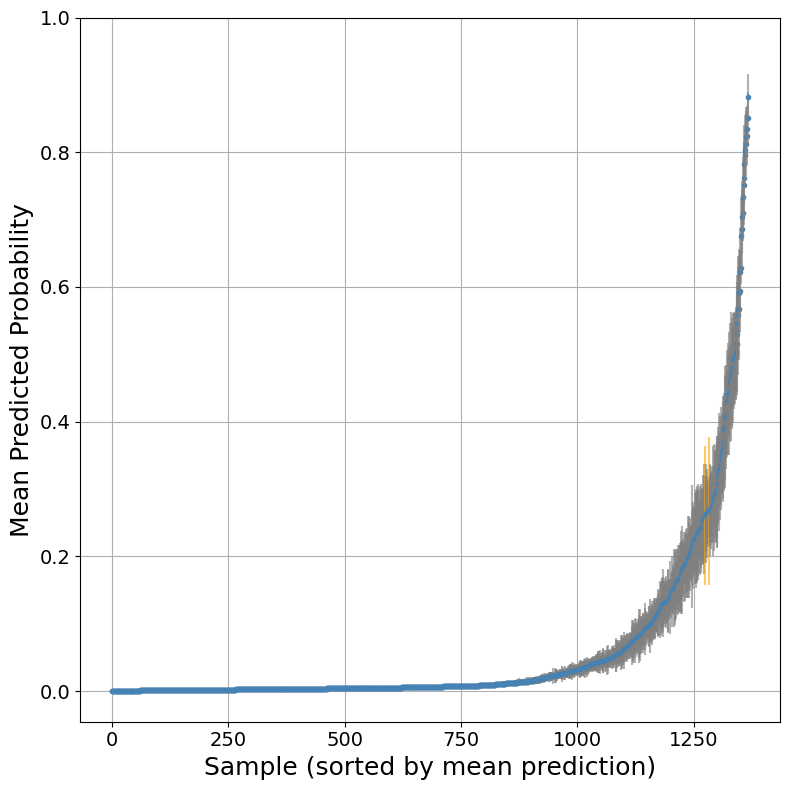

In [39]:
tick_size = 14
label_size = 18
legend_size = 18
text_size = 18
y_ticks_max = agg_df_full_sorted.shape[0]

plt.figure(figsize=(8, 8))

# Loop through each sample
for i in range(len(agg_df_full_sorted)):
    mean = agg_df_full_sorted['mean_prob'].iloc[i]
    std = agg_df_full_sorted['std_prob'].iloc[i]
    
    err_color = 'orange' if std > 0.10 else 'gray'

    # Plot error bar only (no marker)
    plt.errorbar(
        x=i,
        y=mean,
        yerr=std,
        fmt='none',          # No marker
        ecolor=err_color,
        alpha=0.4 if err_color == 'grey' else 0.6,           # Alpha for error bars
        #capsize=2
    )

    # Plot marker separately
    plt.plot(
        i,
        mean,
        'o',
        markersize=3,
        color='steelblue',       # Marker color
        alpha=1           # Alpha for marker
    )

plt.xlabel("Sample (sorted by mean prediction)", size=label_size)
plt.ylabel("Mean Predicted Probability", size=label_size)
plt.yticks(np.arange(0, 1.1, step=0.2), size=tick_size)
plt.xticks(np.arange(0, round(y_ticks_max * 1.05, -2), step=250), size=tick_size)
plt.grid(True)
#plt.legend(prop={'size': legend_size})
plt.tight_layout()
plt.show()


In [40]:
num_high_uncertainty = agg_df_full[agg_df_full['std_prob'] >= 0.10].shape[0]
total_samples = agg_df_full.shape[0]
percentage_high_uncertainty = (num_high_uncertainty / total_samples) * 100
percentage_high_uncertainty

0.14619883040935672

In [41]:
print(f"Average Uncertainty of Predictions: {agg_df_full['std_prob'].mean():.4f}")
print(f"High-risk Uncertainty of Predictions: {agg_df_full[agg_df_full['mean_prob'] >= thr]['std_prob'].mean():.4f}")
print(f"Low-risk Uncertainty of Predictions: {agg_df_full[agg_df_full['mean_prob'] < thr]['std_prob'].mean():.4f}")

Average Uncertainty of Predictions: 0.0112
High-risk Uncertainty of Predictions: 0.0635
Low-risk Uncertainty of Predictions: 0.0088


In [42]:
print(f"Average Entropy of Predictions: {agg_df_full['entropy'].mean():.4f}")
print(f"High-risk Entropy of Predictions: {agg_df_full[agg_df_full['mean_prob'] >= thr]['entropy'].mean():.4f}")
print(f"Low-risk Entropy of Predictions: {agg_df_full[agg_df_full['mean_prob'] < thr]['entropy'].mean():.4f}")

Average Entropy of Predictions: 0.1317
High-risk Entropy of Predictions: 0.6360
Low-risk Entropy of Predictions: 0.1090


In [43]:
print(f"Average Predictive Entropy: {agg_df_full['entropy'].mean():.4f}")
print(f"Average Std Dev of Predictions: {agg_df_full['std_prob'].mean():.4f}")

print(f"Top 5 Most Uncertain Samples by Entropy:\n{agg_df_full.sort_values(by='entropy', ascending=False).head()}")
print(f"Top 5 Most Uncertain Samples by Std Dev:\n{agg_df_full.sort_values(by='std_prob', ascending=False).head()}")

Average Predictive Entropy: 0.1317
Average Std Dev of Predictions: 0.0112
Top 5 Most Uncertain Samples by Entropy:
     index  mean_prob  median_prob  std_prob  y_true   entropy
826   1042   0.498500     0.518394  0.066680       1  0.693143
460    460   0.502772     0.497678  0.067137       0  0.693132
318    318   0.496702     0.488873  0.062879       0  0.693125
443    443   0.494049     0.508901  0.067521       1  0.693076
368    368   0.492854     0.496499  0.068161       0  0.693045
Top 5 Most Uncertain Samples by Std Dev:
     index  mean_prob  median_prob  std_prob  y_true   entropy
72      72   0.267300     0.254894  0.109574       0  0.580555
767    983   0.260608     0.212840  0.103073       0  0.573692
791   1007   0.466762     0.504078  0.096066       1  0.690936
583    799   0.441708     0.460301  0.091527       1  0.686336
65      65   0.214163     0.217910  0.091317       0  0.519420


In [44]:
print(f"Mean of std of the top 20% worst examples {agg_df_full.sort_values(by='std_prob', ascending=False).iloc[:math.ceil(agg_df.shape[0]*0.2)].std_prob.mean():.4f}")
print(f"Std of std of the top 20% worst examples {agg_df_full.sort_values(by='std_prob', ascending=False).iloc[:math.ceil(agg_df.shape[0]*0.2)].std_prob.std():.4f}")

Mean of std of the top 20% worst examples 0.0460
Std of std of the top 20% worst examples 0.0205


In [45]:
data_train_shap = dataset.copy()
#data_train_shap = convert_multiple_cases(data_train_shap, target_col='cases')
data_train_shap['cases'] = data_train_shap['cases'].apply(lambda x: 1 if x > 0 else 0)

X_train = data_train_shap.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train_shap['cases']

sum_negatives = data_train_shap['cases'].value_counts().get(0)
sum_positives = data_train_shap['cases'].value_counts().get(1)

scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)


In [46]:
# Tree explainer

# curently not working with multioutput models

params["scale_pos_weight"] = sum_negatives/sum_positives

model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

tree_explainer = shap.TreeExplainer(model)
#tree_shap_values = tree_explainer.shap_values(X_train_imputed)
tree_shap_values = tree_explainer(X_train_imputed)

In [47]:
location_columns = data_train_shap.iloc[:, :5]
wnv_columns = data_train_shap['cases']

tree_shap_values_df = pd.DataFrame(tree_shap_values.values, columns=X_train.columns)
tree_shap_values_df = pd.concat([location_columns, tree_shap_values_df, wnv_columns], axis=1)

tree_shap_values_df

region_attica = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL30'))
region_macedonia = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL52'))
region_thrace = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL51'))
region_thessaly = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL61'))
region_peloponnese = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL65'))

month_may = (tree_shap_values_df['month'] == 5)
month_jun = (tree_shap_values_df['month'] == 6)
month_jul = (tree_shap_values_df['month'] == 7)
month_aug = (tree_shap_values_df['month'] == 8)
month_sep = (tree_shap_values_df['month'] == 9)
month_oct = (tree_shap_values_df['month'] == 10)

shap_values_df_attica = tree_shap_values_df[region_attica].iloc[:, 5:-1].to_numpy()
shap_values_df_macedonia = tree_shap_values_df[region_macedonia].iloc[:, 5:-1].to_numpy()
shap_values_df_thrace = tree_shap_values_df[region_thrace].iloc[:, 5:-1].to_numpy()
shap_values_df_thessaly = tree_shap_values_df[region_thessaly].iloc[:, 5:-1].to_numpy()
shap_values_df_peloponnese = tree_shap_values_df[region_peloponnese].iloc[:, 5:-1].to_numpy()

shap_values_df_may = tree_shap_values_df[month_may].iloc[:, 5:-1].to_numpy()
shap_values_df_jun = tree_shap_values_df[month_jun].iloc[:, 5:-1].to_numpy()
shap_values_df_jul = tree_shap_values_df[month_jul].iloc[:, 5:-1].to_numpy()
shap_values_df_aug = tree_shap_values_df[month_aug].iloc[:, 5:-1].to_numpy()
shap_values_df_sep = tree_shap_values_df[month_sep].iloc[:, 5:-1].to_numpy()
shap_values_df_oct = tree_shap_values_df[month_oct].iloc[:, 5:-1].to_numpy()

sorted_mean_abs_values_idx = tree_shap_values_df.iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index

sorted_mean_abs_values_idx_attica = tree_shap_values_df[region_attica].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
sorted_mean_abs_values_idx_macedonia = tree_shap_values_df[region_macedonia].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
sorted_mean_abs_values_idx_thrace = tree_shap_values_df[region_thrace].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
sorted_mean_abs_values_idx_thessaly = tree_shap_values_df[region_thessaly].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
sorted_mean_abs_values_idx_peloponnese = tree_shap_values_df[region_peloponnese].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index

sorted_mean_abs_values_idx_may = tree_shap_values_df[month_may].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
sorted_mean_abs_values_idx_jun = tree_shap_values_df[month_jun].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
sorted_mean_abs_values_idx_jul = tree_shap_values_df[month_jul].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
sorted_mean_abs_values_idx_aug = tree_shap_values_df[month_aug].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
sorted_mean_abs_values_idx_sep = tree_shap_values_df[month_sep].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
sorted_mean_abs_values_idx_oct = tree_shap_values_df[month_oct].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index


In [48]:
tree_shap_values_df[month_oct].month.unique()

array([10], dtype=int64)

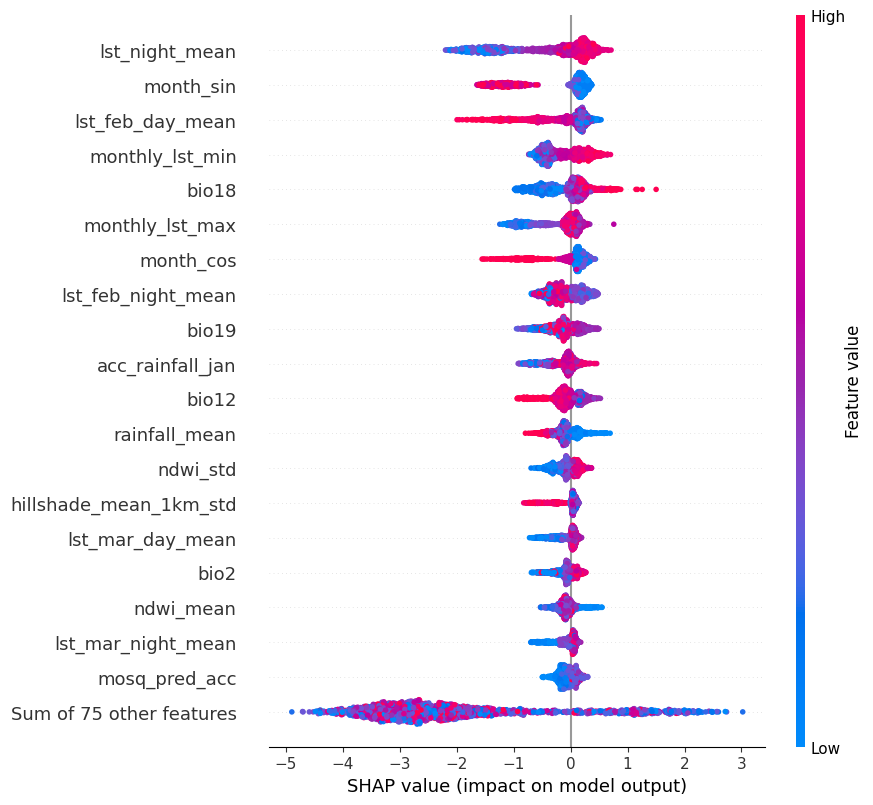

In [49]:
shap.plots.beeswarm(shap_values = tree_shap_values, max_display=20)

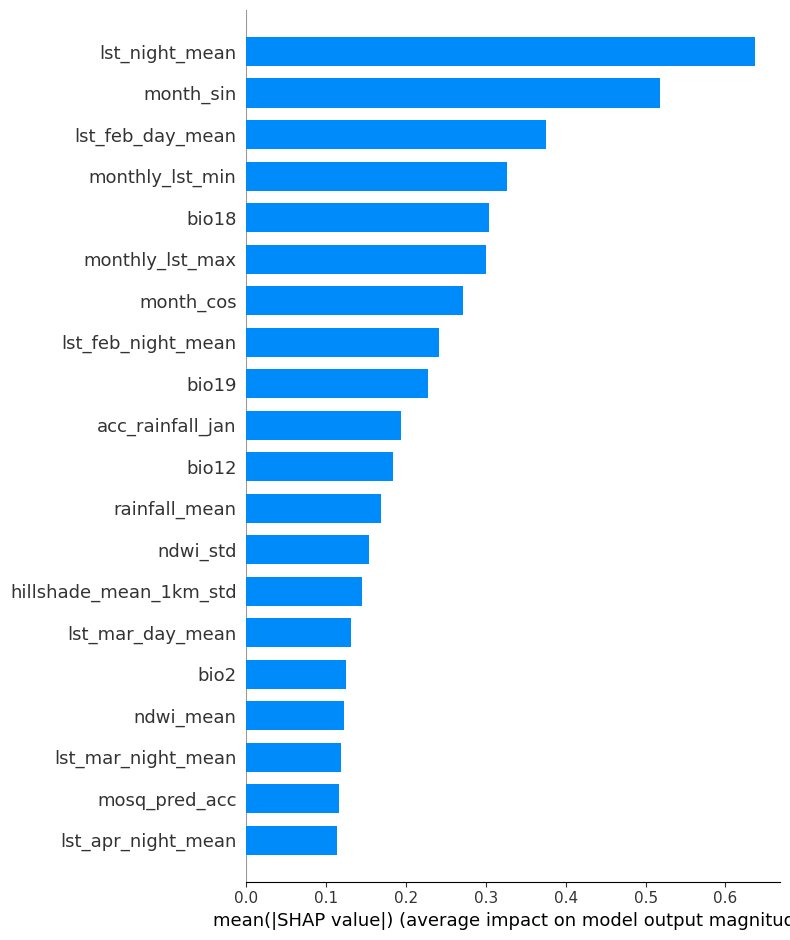

In [50]:
shap.summary_plot(tree_shap_values, feature_names = X_train.columns, features = X_train_imputed, plot_type='bar', max_display=20)

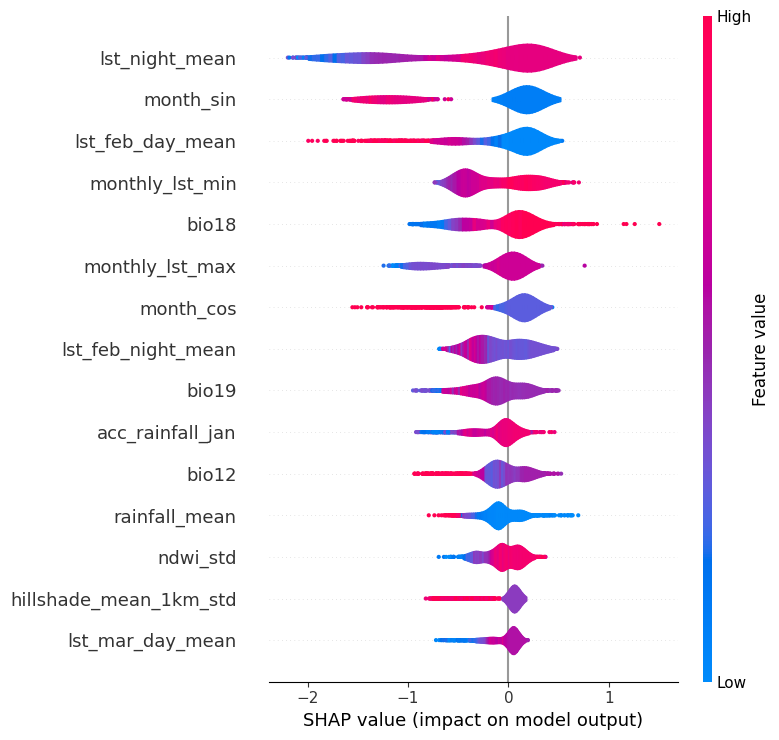

In [51]:
shap.summary_plot(tree_shap_values, feature_names = X_train.columns, features = X_train_imputed, plot_type='violin', max_display=15)

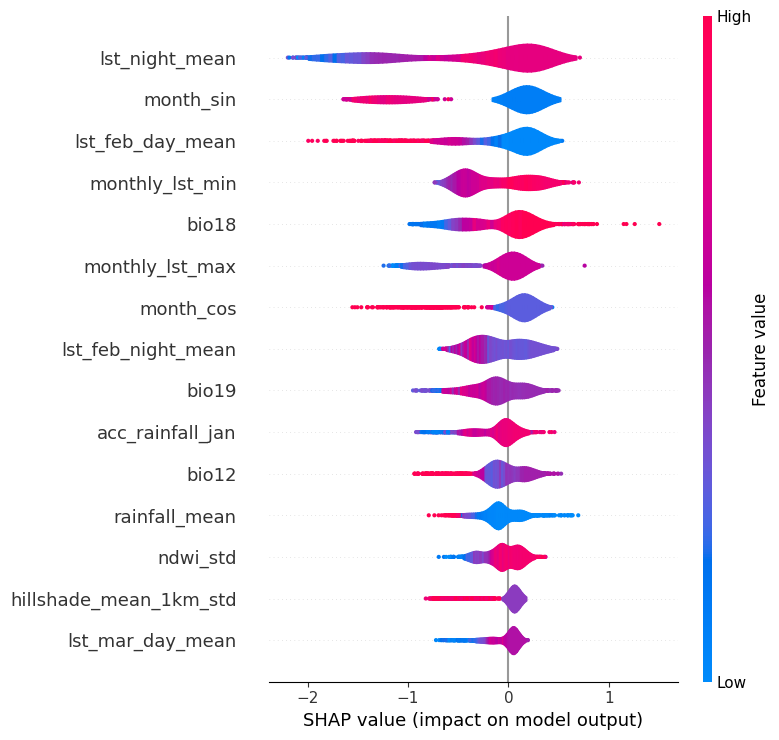

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))  # (width, height) in inches

shap.summary_plot(
    tree_shap_values,
    features=X_train_imputed,
    feature_names=X_train.columns,
    plot_type='violin',
    max_display=15,
    show=False
)

plt.show()

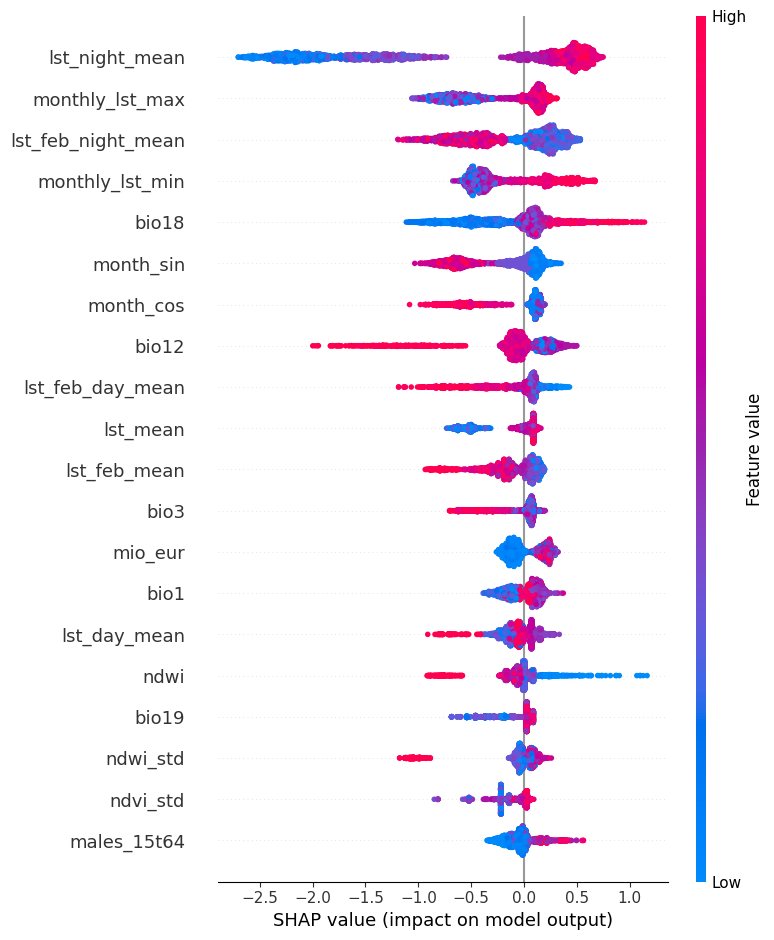

In [36]:
shap.summary_plot(tree_shap_values.values, feature_names = X_train.columns, features = tree_shap_values.data, max_display=20)

### Plots For All Regions ###

In [37]:
shap_lim = (-3, 3)
lowess_it = 3
lowess_frac = 0.5
shap_alpha = 0.5

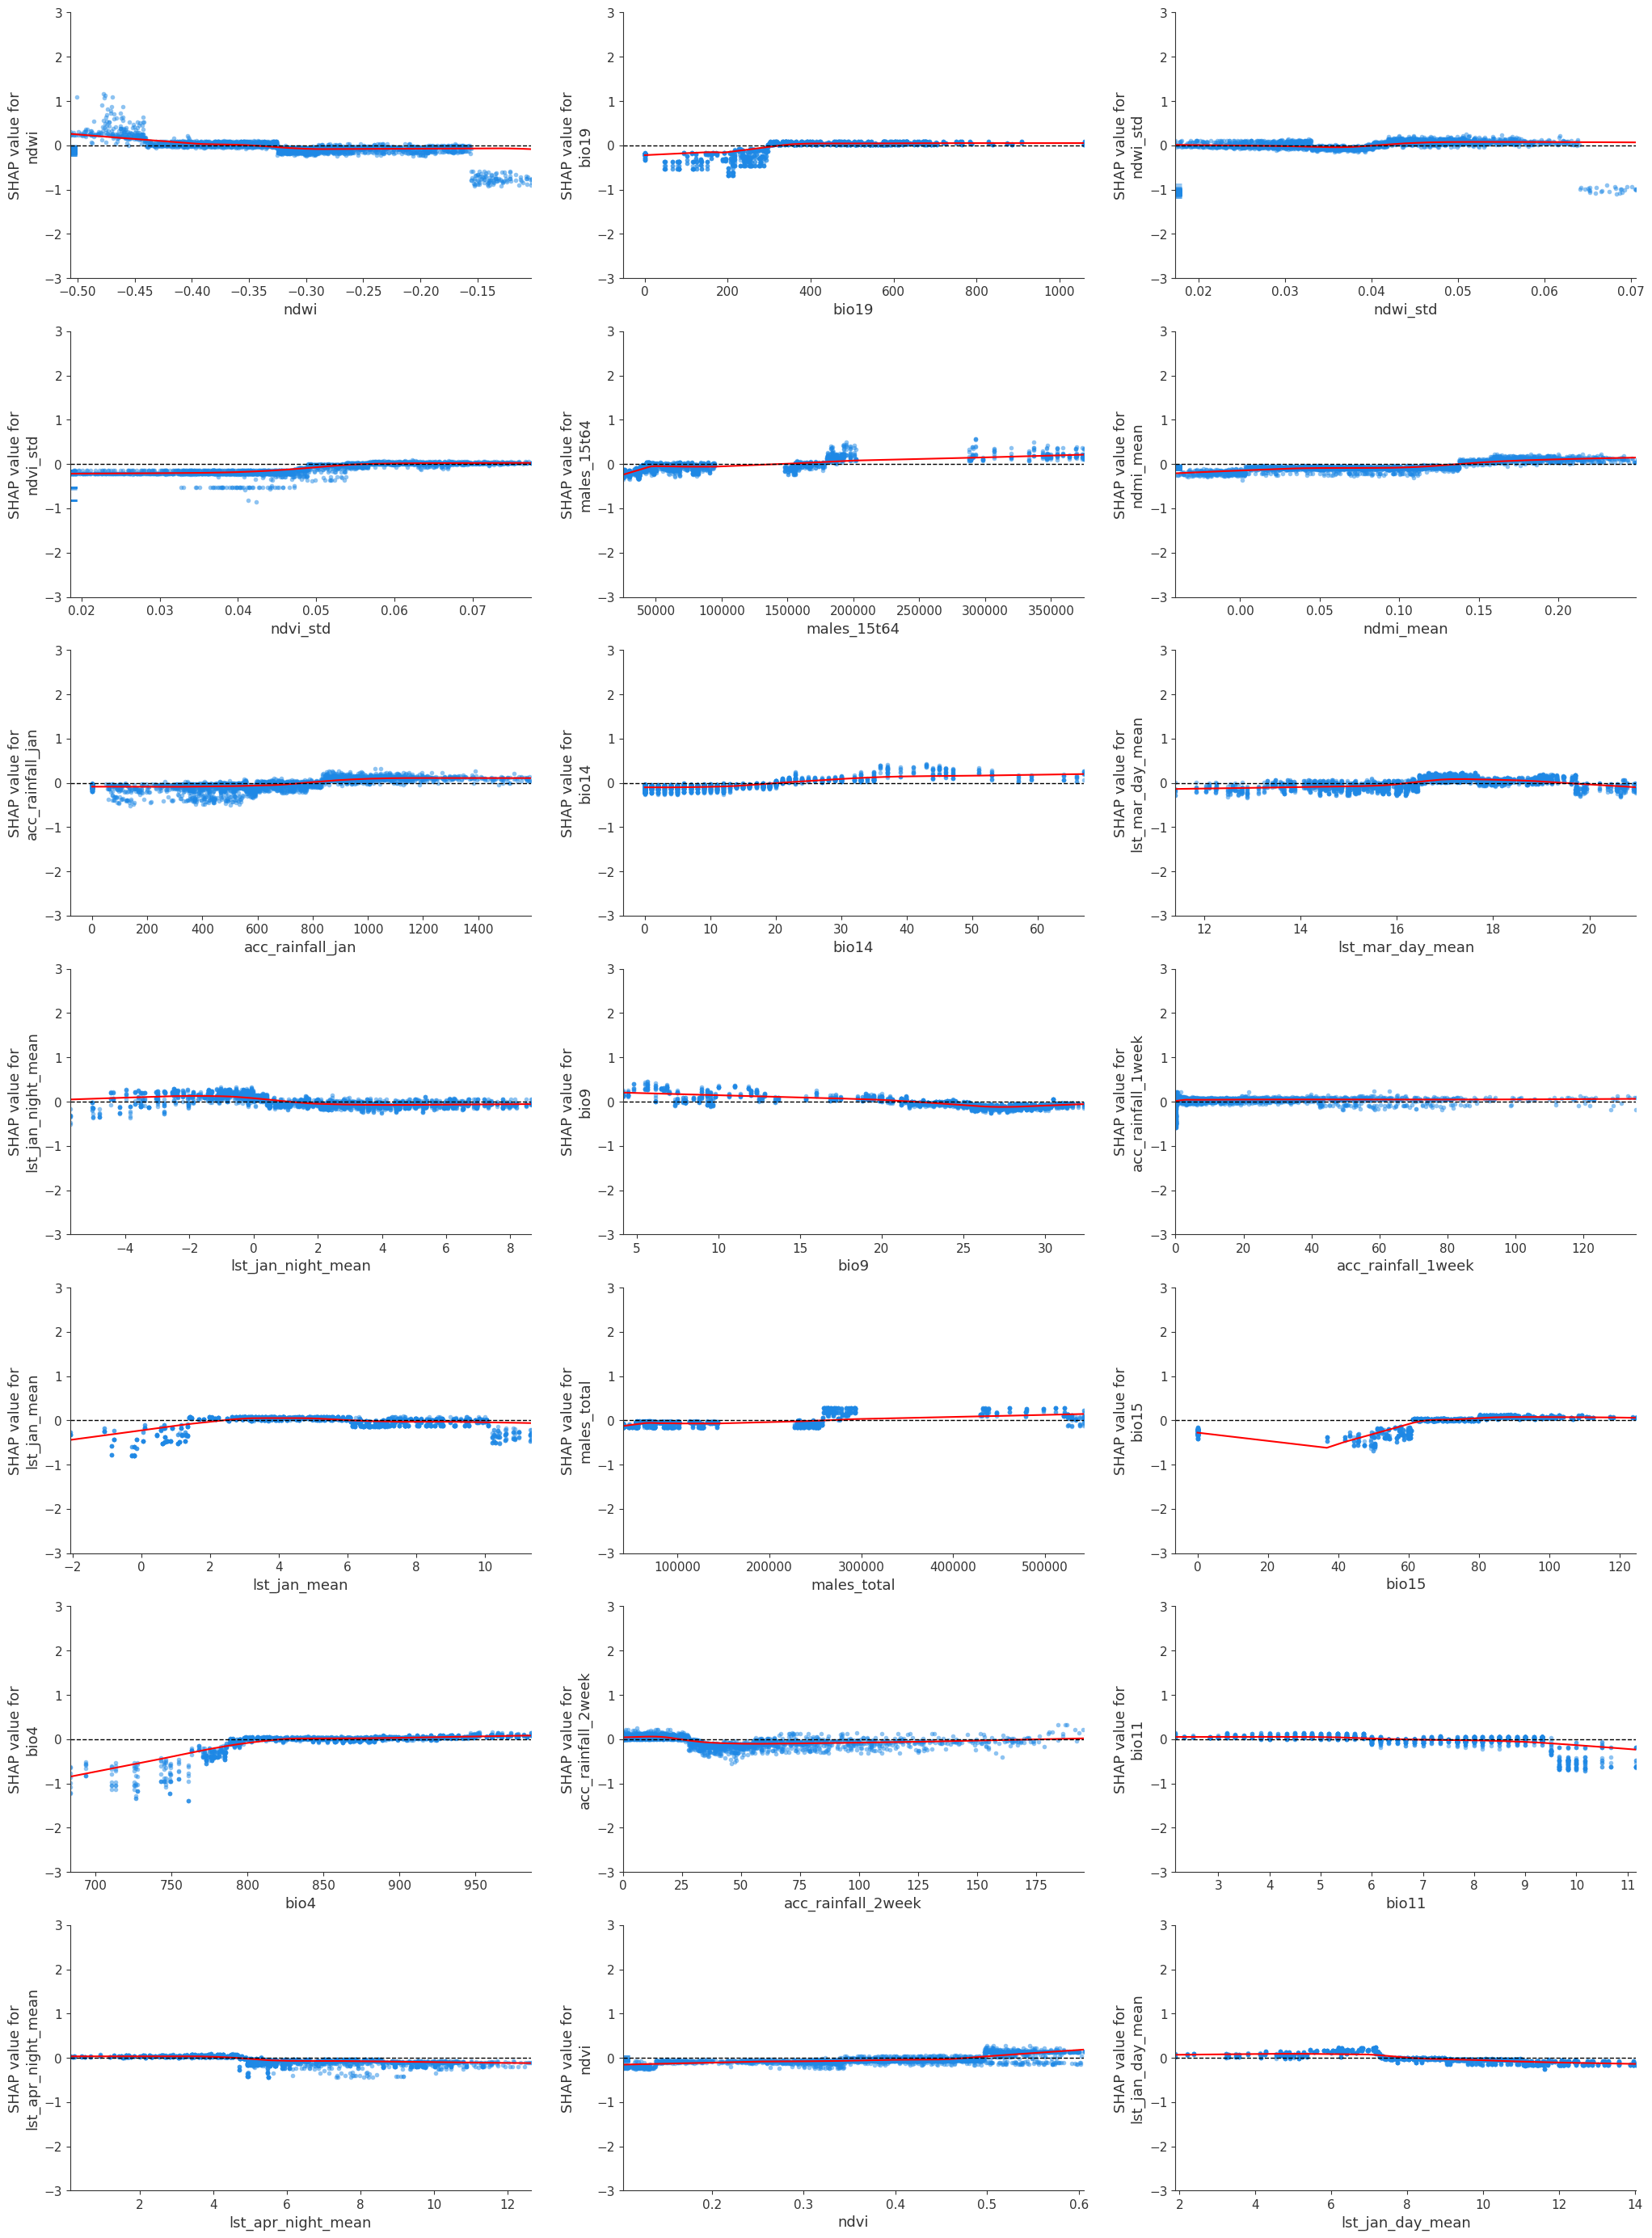

In [44]:
num_plots = 36

fig, axes = plt.subplots(7, 3, figsize=(25, 35))  # Adjust figsize as needed
i = 0

for ft in sorted_mean_abs_values_idx[15:num_plots]:
    row = i // 3
    col = i % 3

    ax = axes[row, col]
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = data.columns

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=lowess_it, frac=lowess_frac)
    
    # ax.set_facecolor('lightgrey')
    ax.plot(*list(zip(*lowess)), color="red", lw=1.5)
    ax.axhline(y=0, color='black', linestyle='--', lw=1)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind=feature, shap_values=shap_values, features=data, 
                         feature_names=feature_names, interaction_index=None, 
                         xmin="percentile(1)", xmax="percentile(99)", alpha=shap_alpha, ax=ax, show = False)
    
    i = i+1

plt.show()

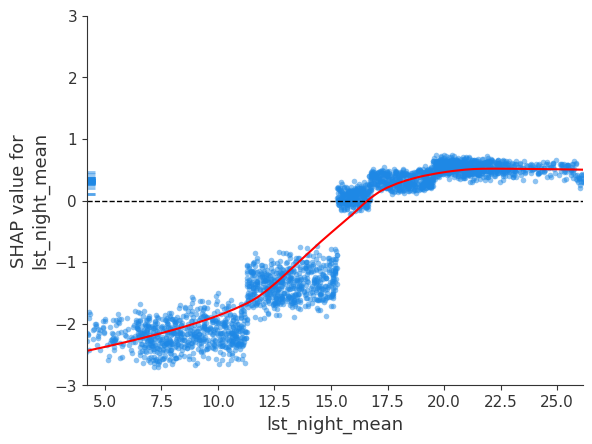

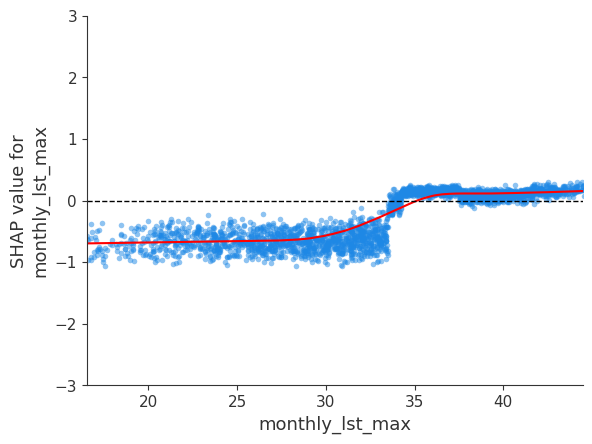

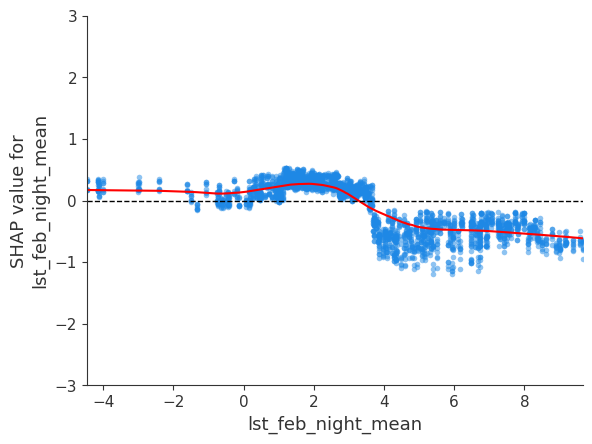

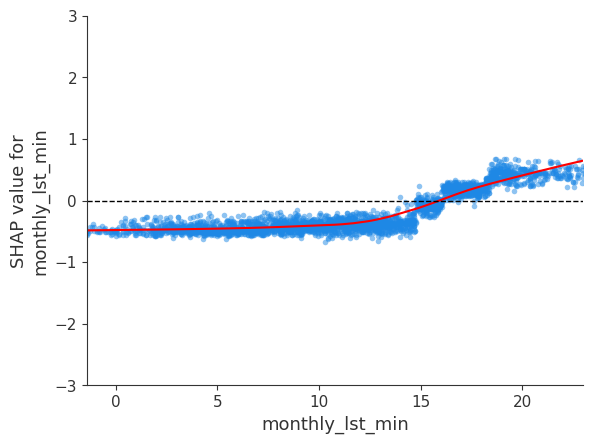

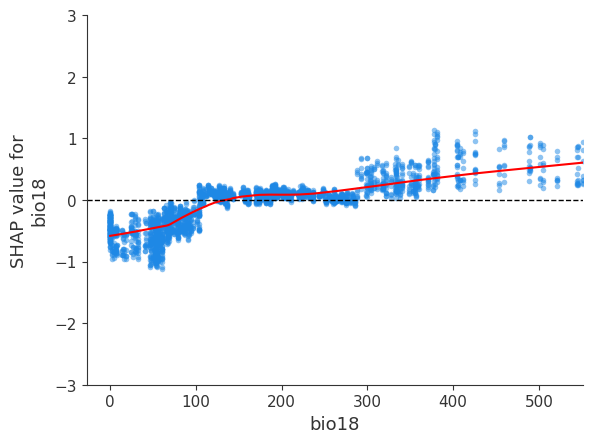

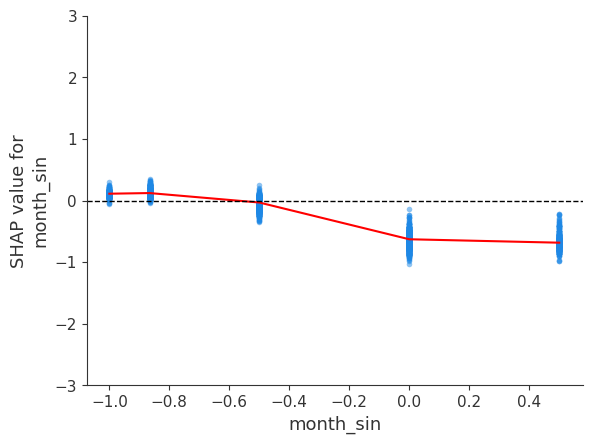

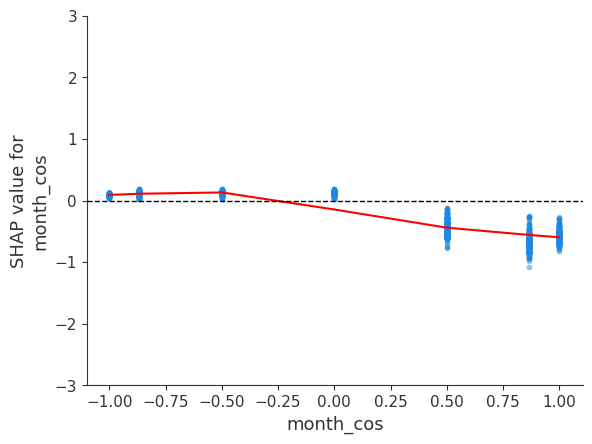

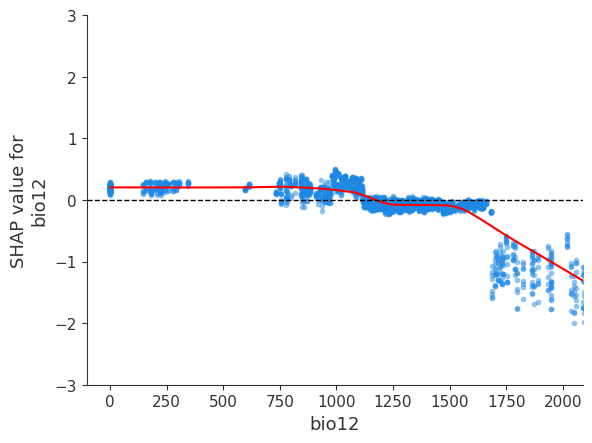

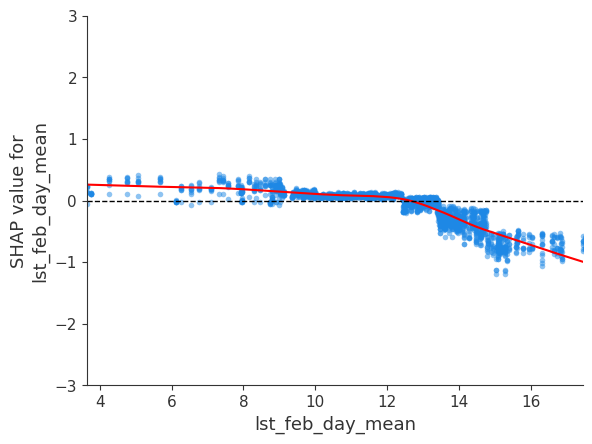

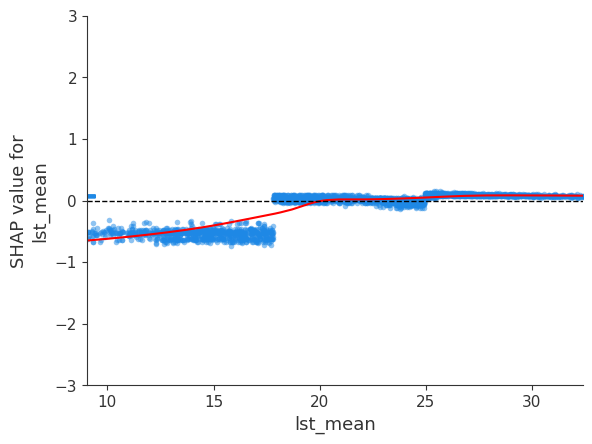

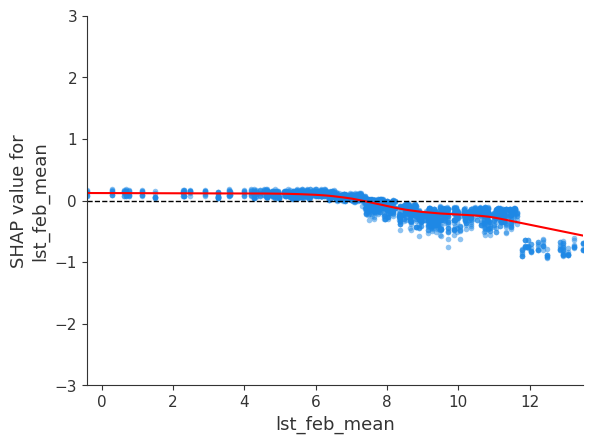

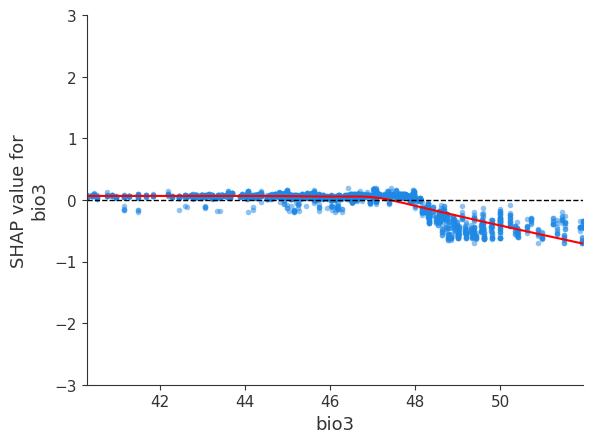

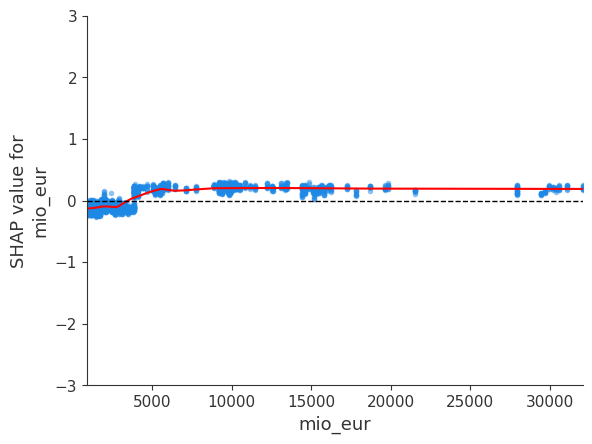

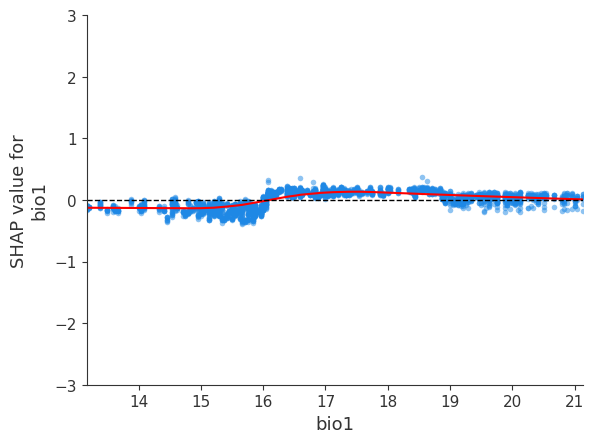

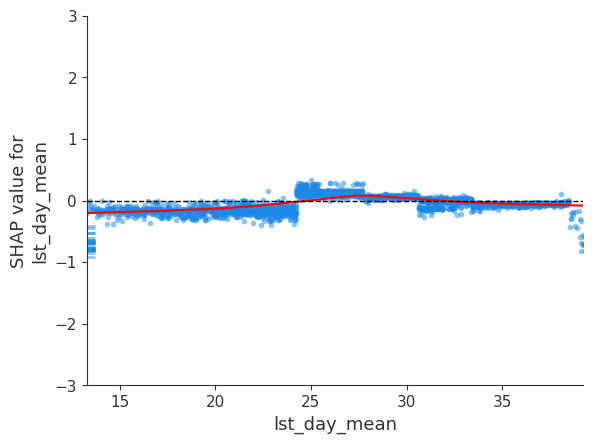

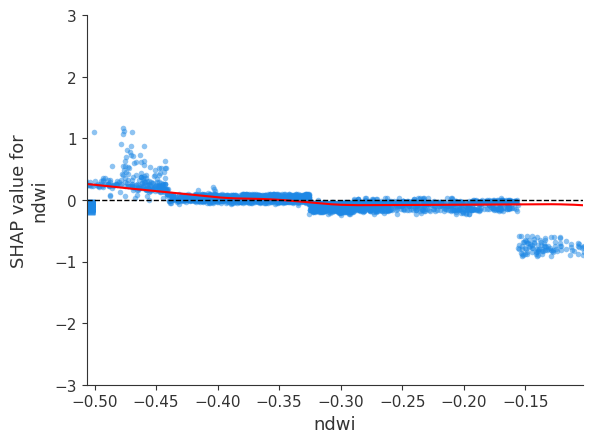

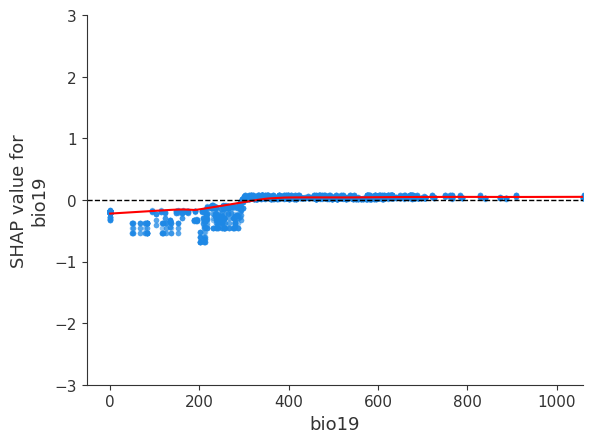

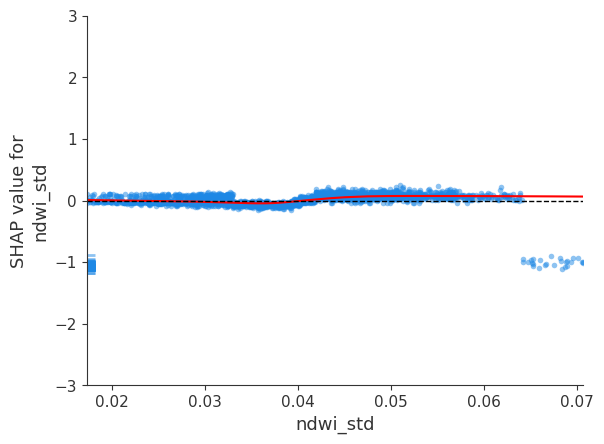

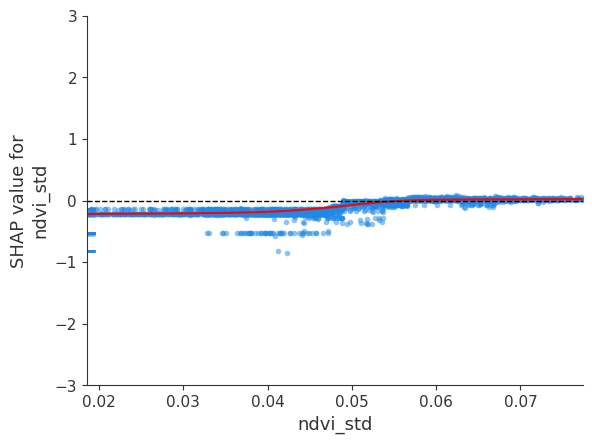

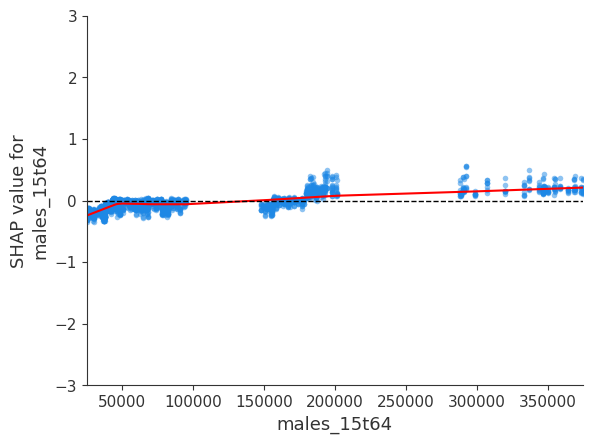

In [40]:
for ft in sorted_mean_abs_values_idx[:20]:
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = X_train.columns

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=lowess_it,frac=lowess_frac)
    _,ax = plt.subplots()
    # ax.set_facecolor('lightgrey')
    ax.plot(*list(zip(*lowess)), color="red", lw=1.5)
    ax.axhline(y=0, color='black', linestyle='--', lw=1)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind = feature, shap_values = shap_values, features = X_train, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(1)", xmax="percentile(99)", alpha=shap_alpha, ax = ax)

### Region-Based Comparison ###

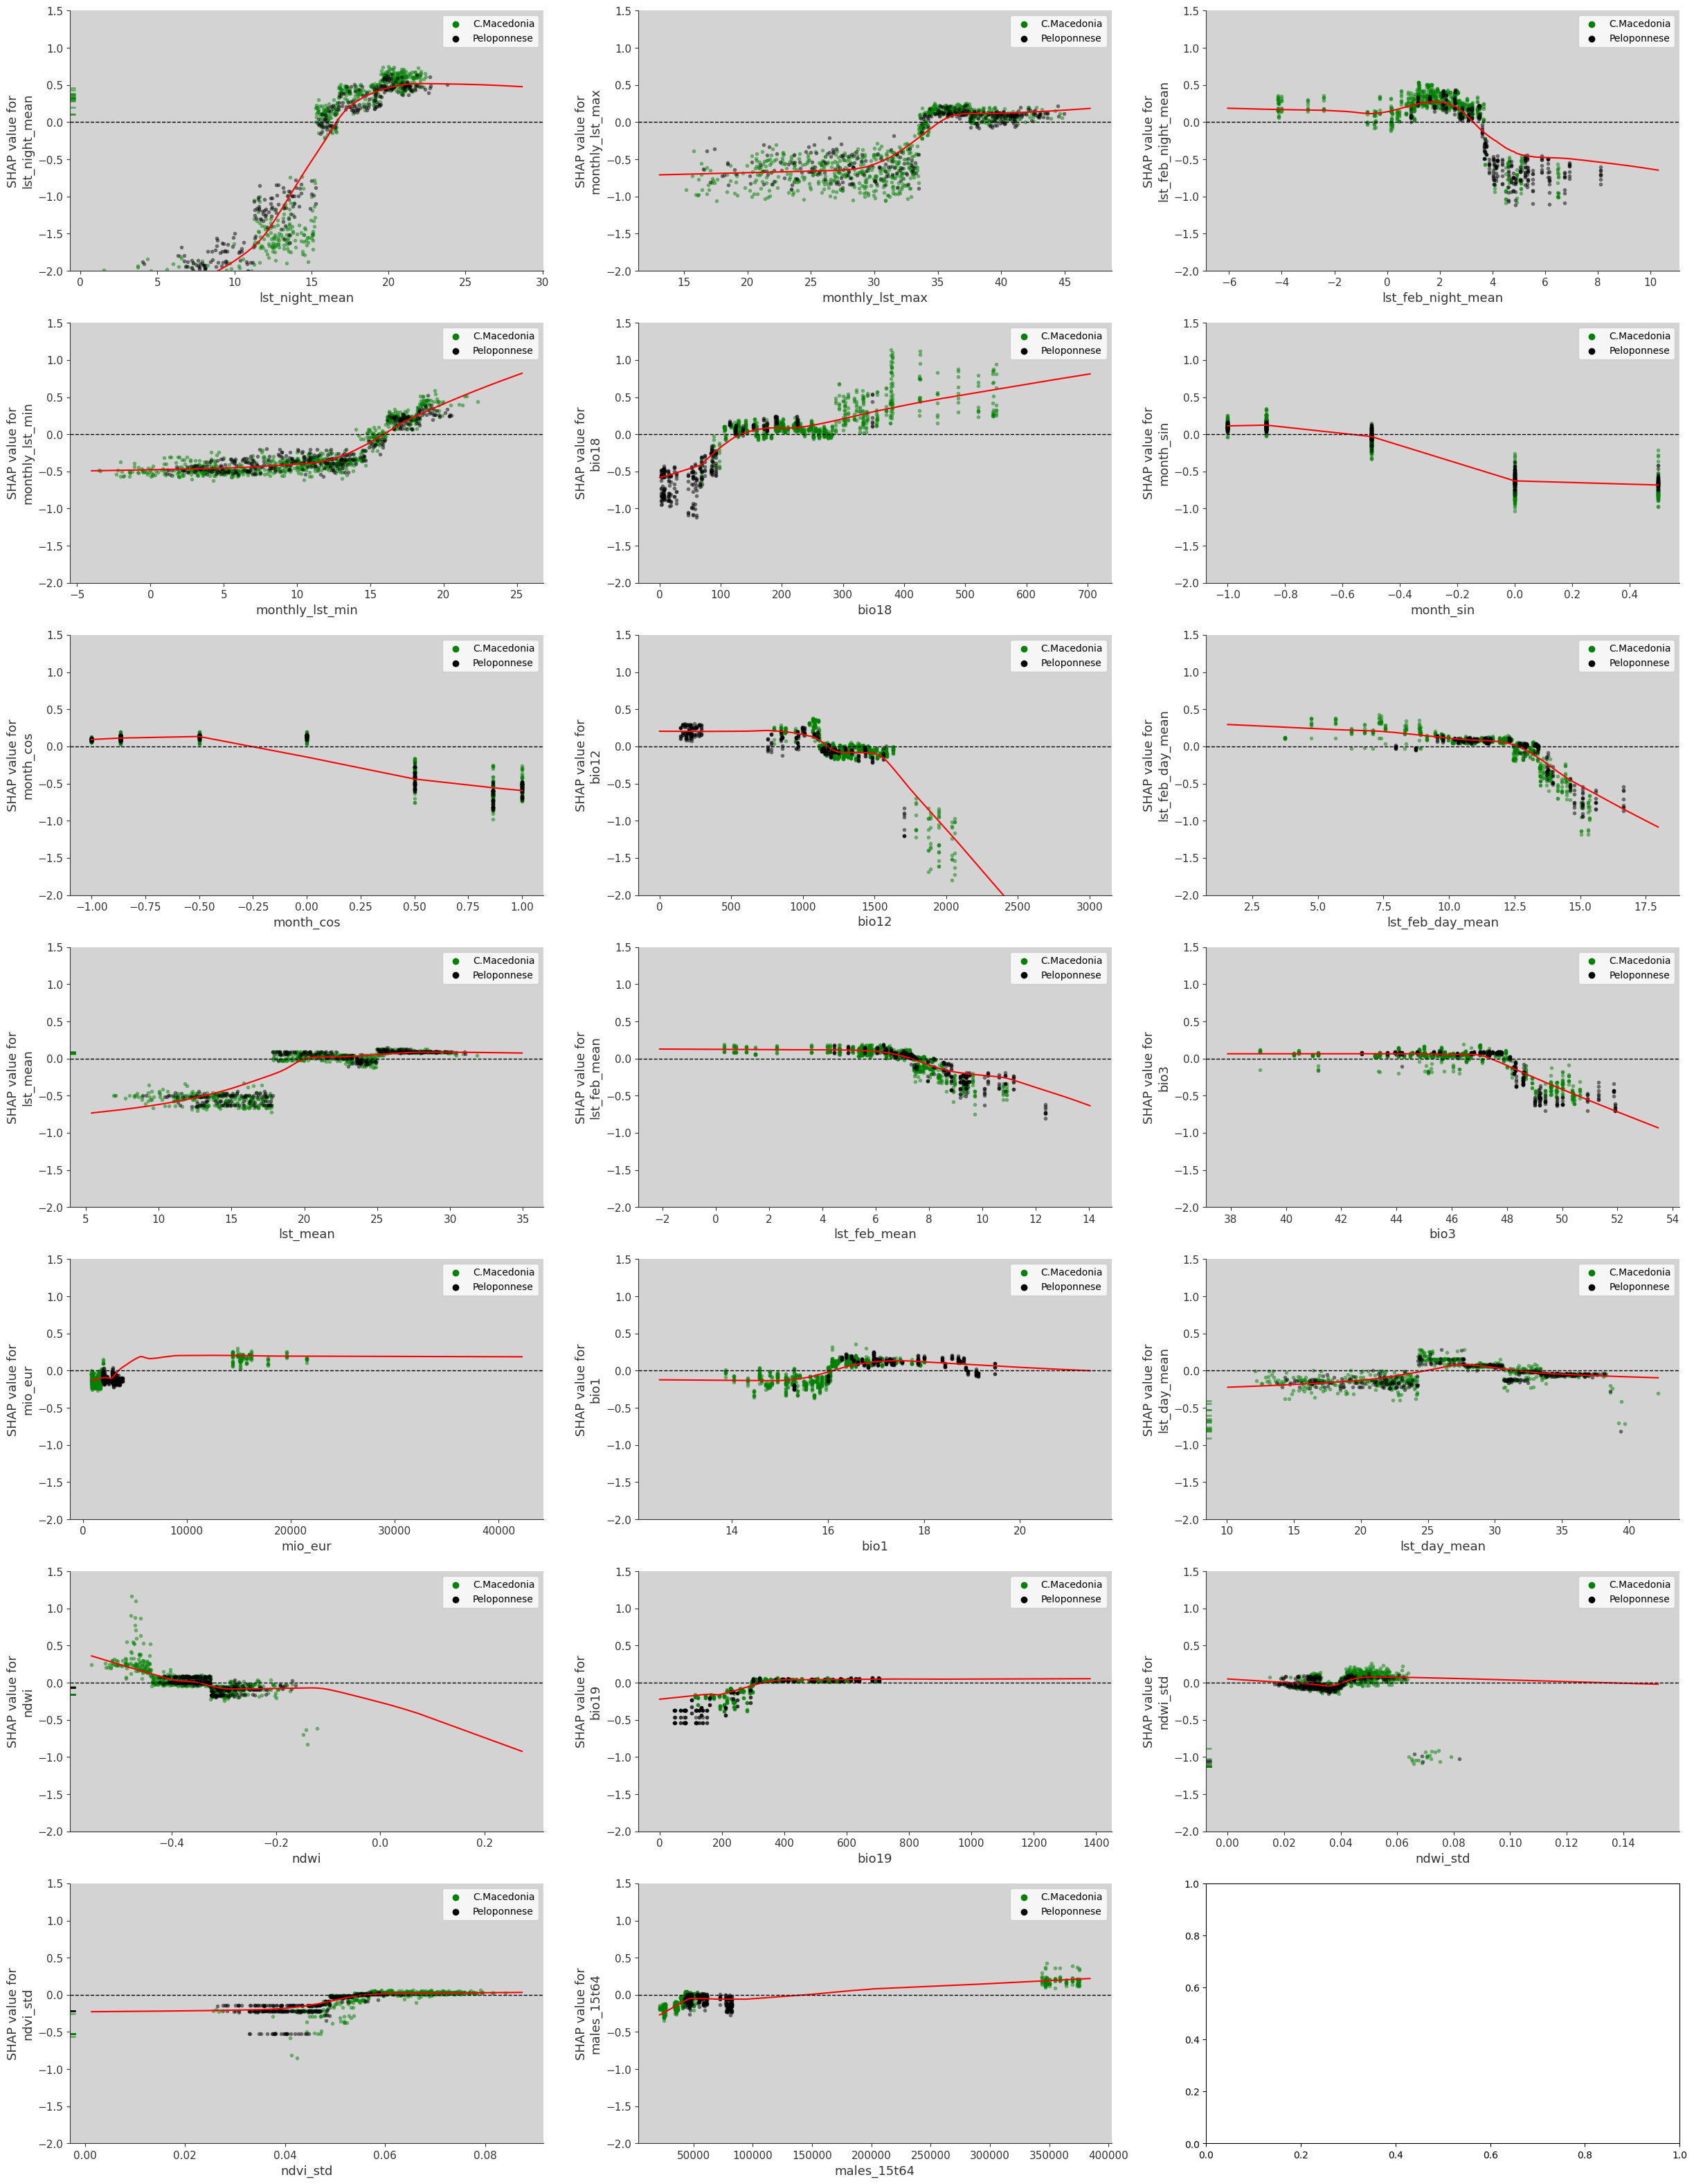

In [39]:
num_plots = 20

fig, axes = plt.subplots(7, 3, figsize=(30, 40))  # Adjust figsize as needed

i = 0
# for ft in ['monthly_lst_min','monthly_lst_max', 'lst_mean', 'lst_day_mean', 'lst_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_feb_mean', 'bio12', 'bio3', 'bio18', 'bio19']:
for ft in sorted_mean_abs_values_idx[:num_plots]:
    row = i // 3
    col = i % 3
    
    ax = axes[row, col]
    ax.set_facecolor('lightgrey')
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = data.columns

    shap_values_at = shap_values_df_attica
    data_at = X_train[region_attica]

    shap_values_cm = shap_values_df_macedonia
    data_cm = X_train[region_macedonia]

    shap_values_em = shap_values_df_thrace
    data_em = X_train[region_thrace]

    shap_values_th = shap_values_df_thessaly
    data_th = X_train[region_thessaly]

    shap_values_pl = shap_values_df_peloponnese
    data_pl = X_train[region_peloponnese]

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=lowess_it, frac=lowess_frac)
    
    ax.plot(*list(zip(*lowess)), color="red", lw=1.5)
    ax.axhline(y=0, color='black', linestyle='--', lw=1)
    ax.set_ylim(shap_lim)
    
    # shap.dependence_plot(ind=feature, shap_values=shap_values_at, features=data_at, feature_names=feature_names, interaction_index=None, 
    #                      color='blue', alpha=shap_alpha, ax=ax, show = False)
    # ax.scatter([], [], label='Attica', color='blue')

    shap.dependence_plot(ind=feature, shap_values=shap_values_cm, features=data_cm, feature_names=feature_names, interaction_index=None, 
                         color='green', alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='C.Macedonia', color='green')
    
    # shap.dependence_plot(ind=feature, shap_values=shap_values_em, features=data_em, feature_names=feature_names, interaction_index=None, 
    #                      color='orange', alpha=shap_alpha, ax=ax, show = False)
    # ax.scatter([], [], label='Thrace', color='orange')
    
    # shap.dependence_plot(ind=feature, shap_values=shap_values_th, features=data_th, feature_names=feature_names, interaction_index=None, 
    #                      color='fuchsia', alpha=shap_alpha, ax=ax, show = False)
    # ax.scatter([], [], label='Thessaly', color='fuchsia')

    shap.dependence_plot(ind=feature, shap_values=shap_values_pl, features=data_pl, feature_names=feature_names, interaction_index=None, 
                         color='black', alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='Peloponnese', color='black')
    
    ax.legend()
    
    i = i+1

plt.show()

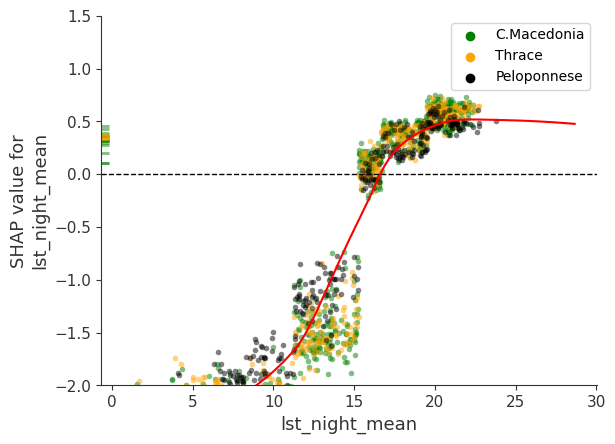

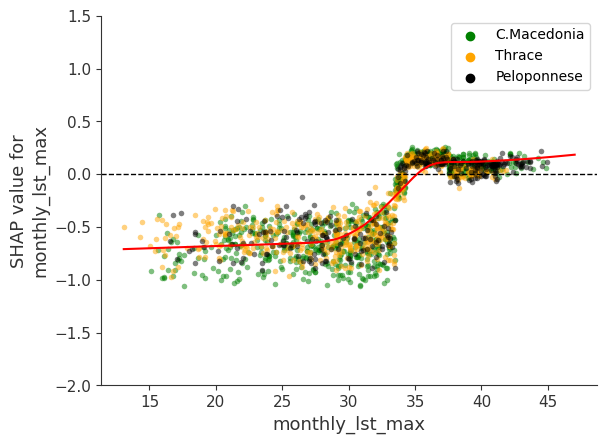

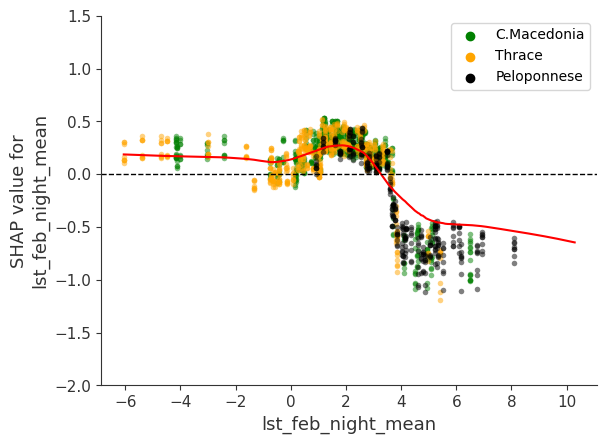

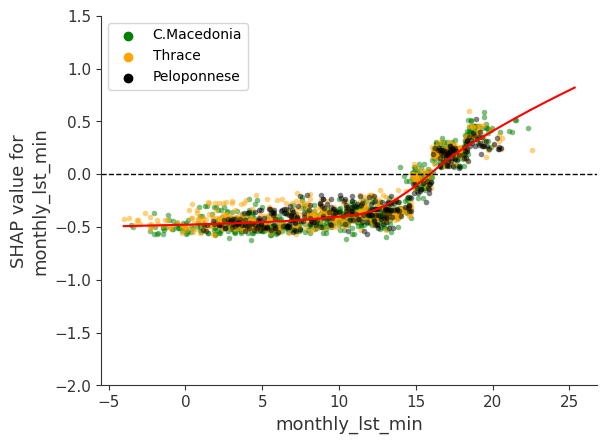

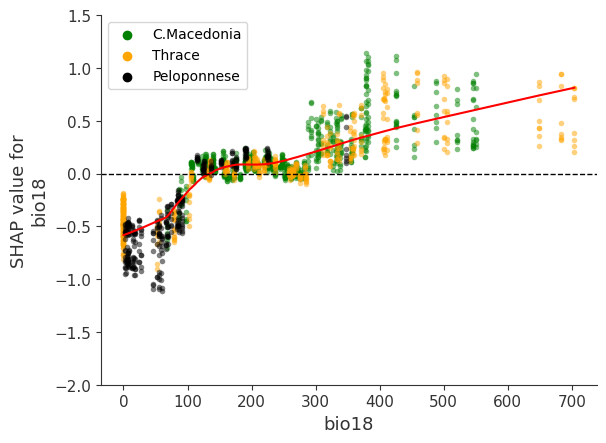

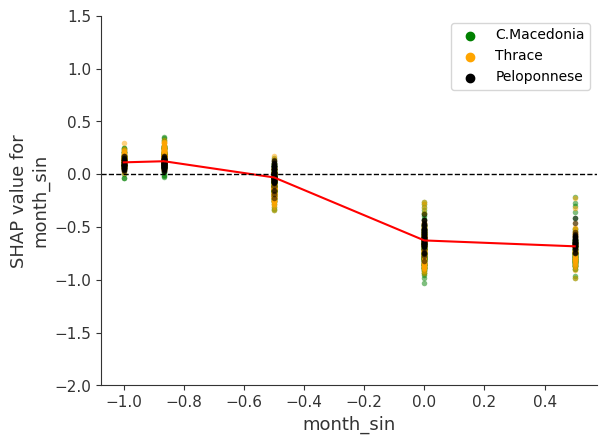

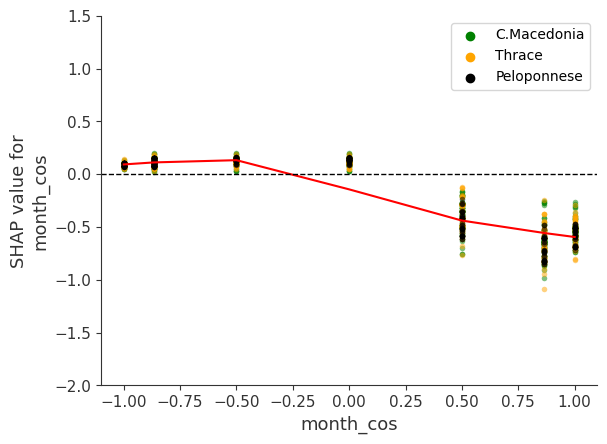

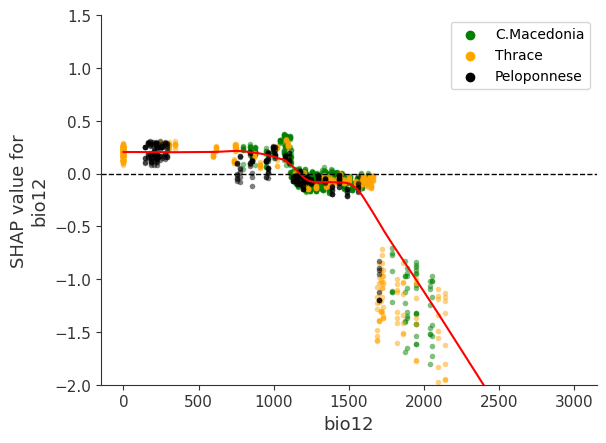

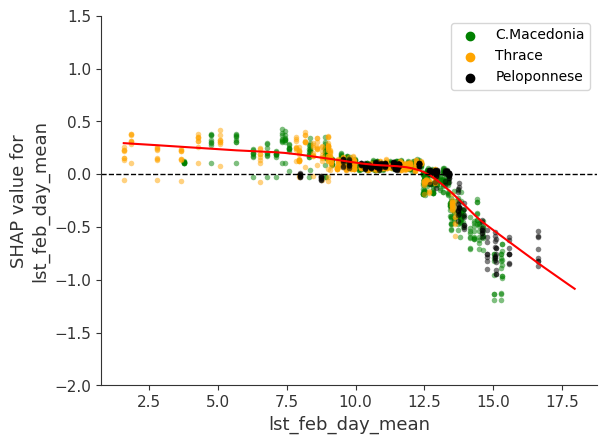

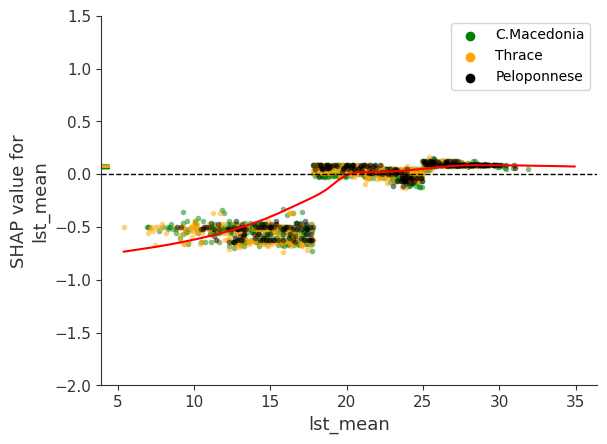

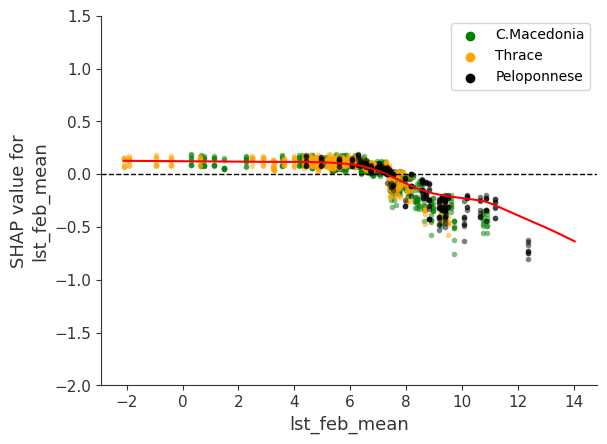

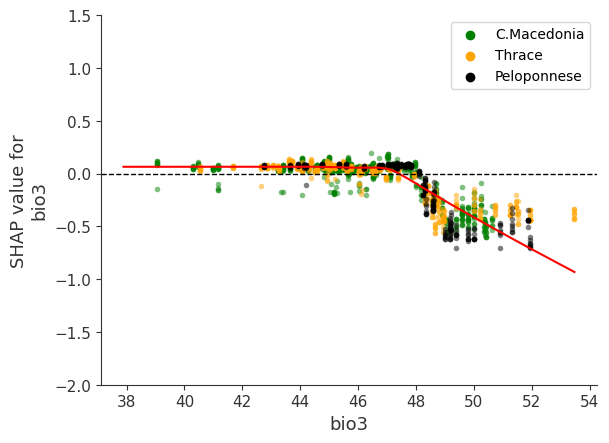

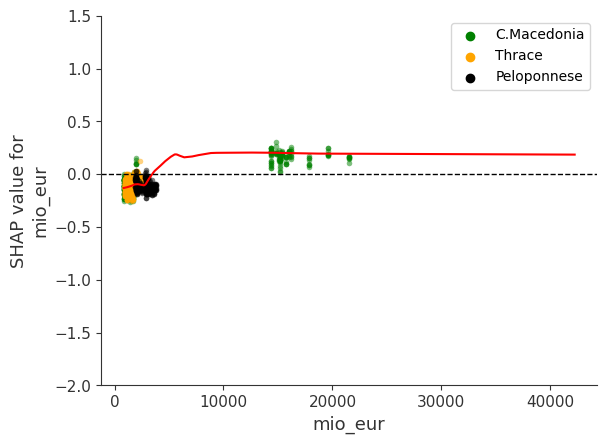

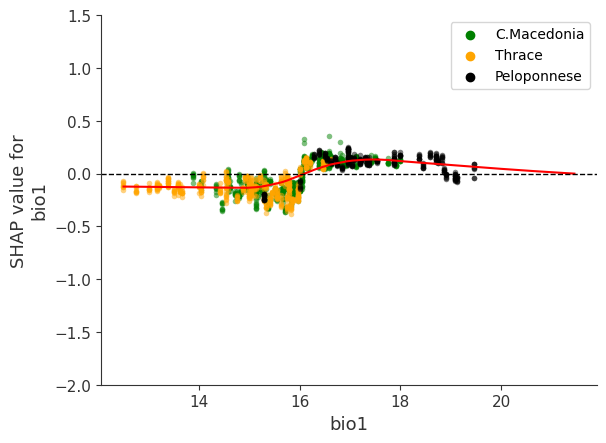

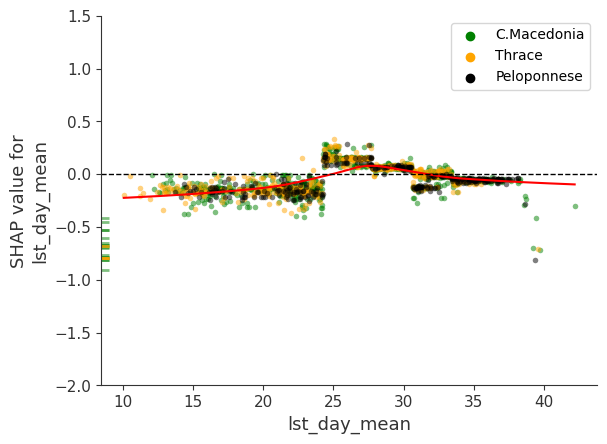

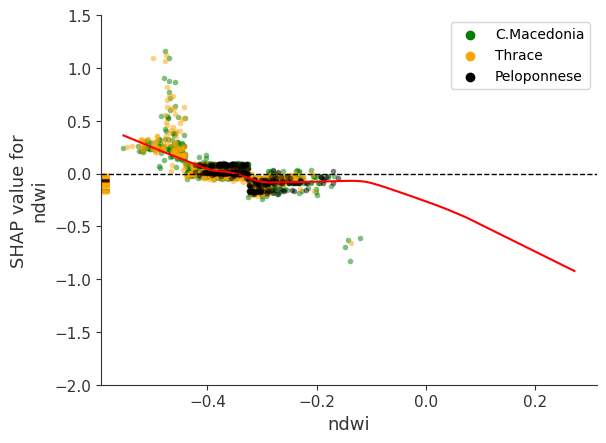

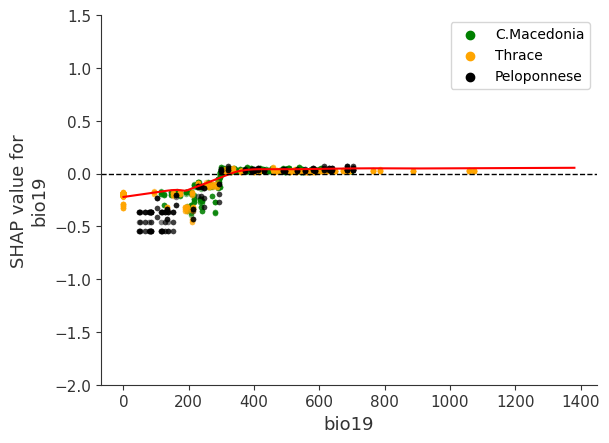

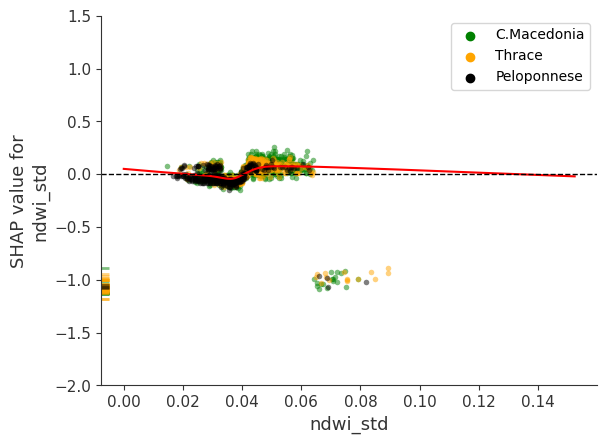

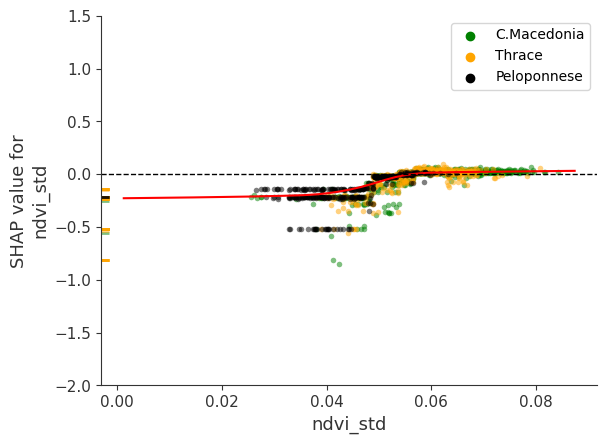

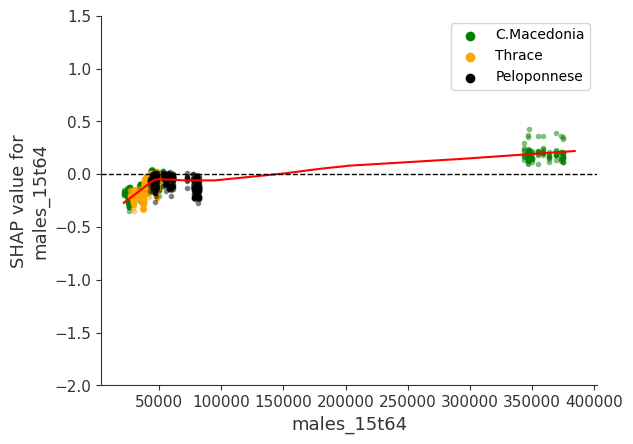

In [40]:
#for ft in ['monthly_lst_min','monthly_lst_max', 'lst_mean', 'lst_day_mean', 'lst_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_feb_mean', 'bio12', 'bio3', 'bio18', 'bio19']:
for ft in sorted_mean_abs_values_idx[:num_plots]:
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = X_train.columns

    shap_values_at = shap_values_df_attica
    data_at = X_train[region_attica]

    shap_values_cm = shap_values_df_macedonia
    data_cm = X_train[region_macedonia]

    shap_values_em = shap_values_df_thrace
    data_em = X_train[region_thrace]

    shap_values_th = shap_values_df_thessaly
    data_th = X_train[region_thessaly]

    shap_values_pl = shap_values_df_peloponnese
    data_pl = X_train[region_peloponnese]

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=lowess_it,frac=lowess_frac)
    _,ax = plt.subplots()
    # ax.set_facecolor('lightgrey')
    ax.plot(*list(zip(*lowess)), color="red", lw = 1.5)
    ax.axhline(y=0, color='black', linestyle='--', lw=1)
    ax.set_ylim(shap_lim)
    
    # shap.dependence_plot(ind=feature, shap_values=shap_values_at, features=data_at, feature_names=feature_names, interaction_index=None, 
    #                      color='blue', alpha=shap_alpha, ax=ax, show = False)
    # ax.scatter([], [], label='Attica', color='blue')

    shap.dependence_plot(ind=feature, shap_values=shap_values_cm, features=data_cm, feature_names=feature_names, interaction_index=None, 
                         color='green', alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='C.Macedonia', color='green')
    
    shap.dependence_plot(ind=feature, shap_values=shap_values_em, features=data_em, feature_names=feature_names, interaction_index=None, 
                         color='orange', alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='Thrace', color='orange')
    
    # shap.dependence_plot(ind=feature, shap_values=shap_values_th, features=data_th, feature_names=feature_names, interaction_index=None, 
    #                      color='fuchsia', alpha=shap_alpha, ax=ax, show = False)
    # ax.scatter([], [], label='Thessaly', color='fuchsia')

    shap.dependence_plot(ind=feature, shap_values=shap_values_pl, features=data_pl, feature_names=feature_names, interaction_index=None, 
                         color='black', alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='Peloponnese', color='black')
    
    ax.legend()

### Month-Based Comparison ###

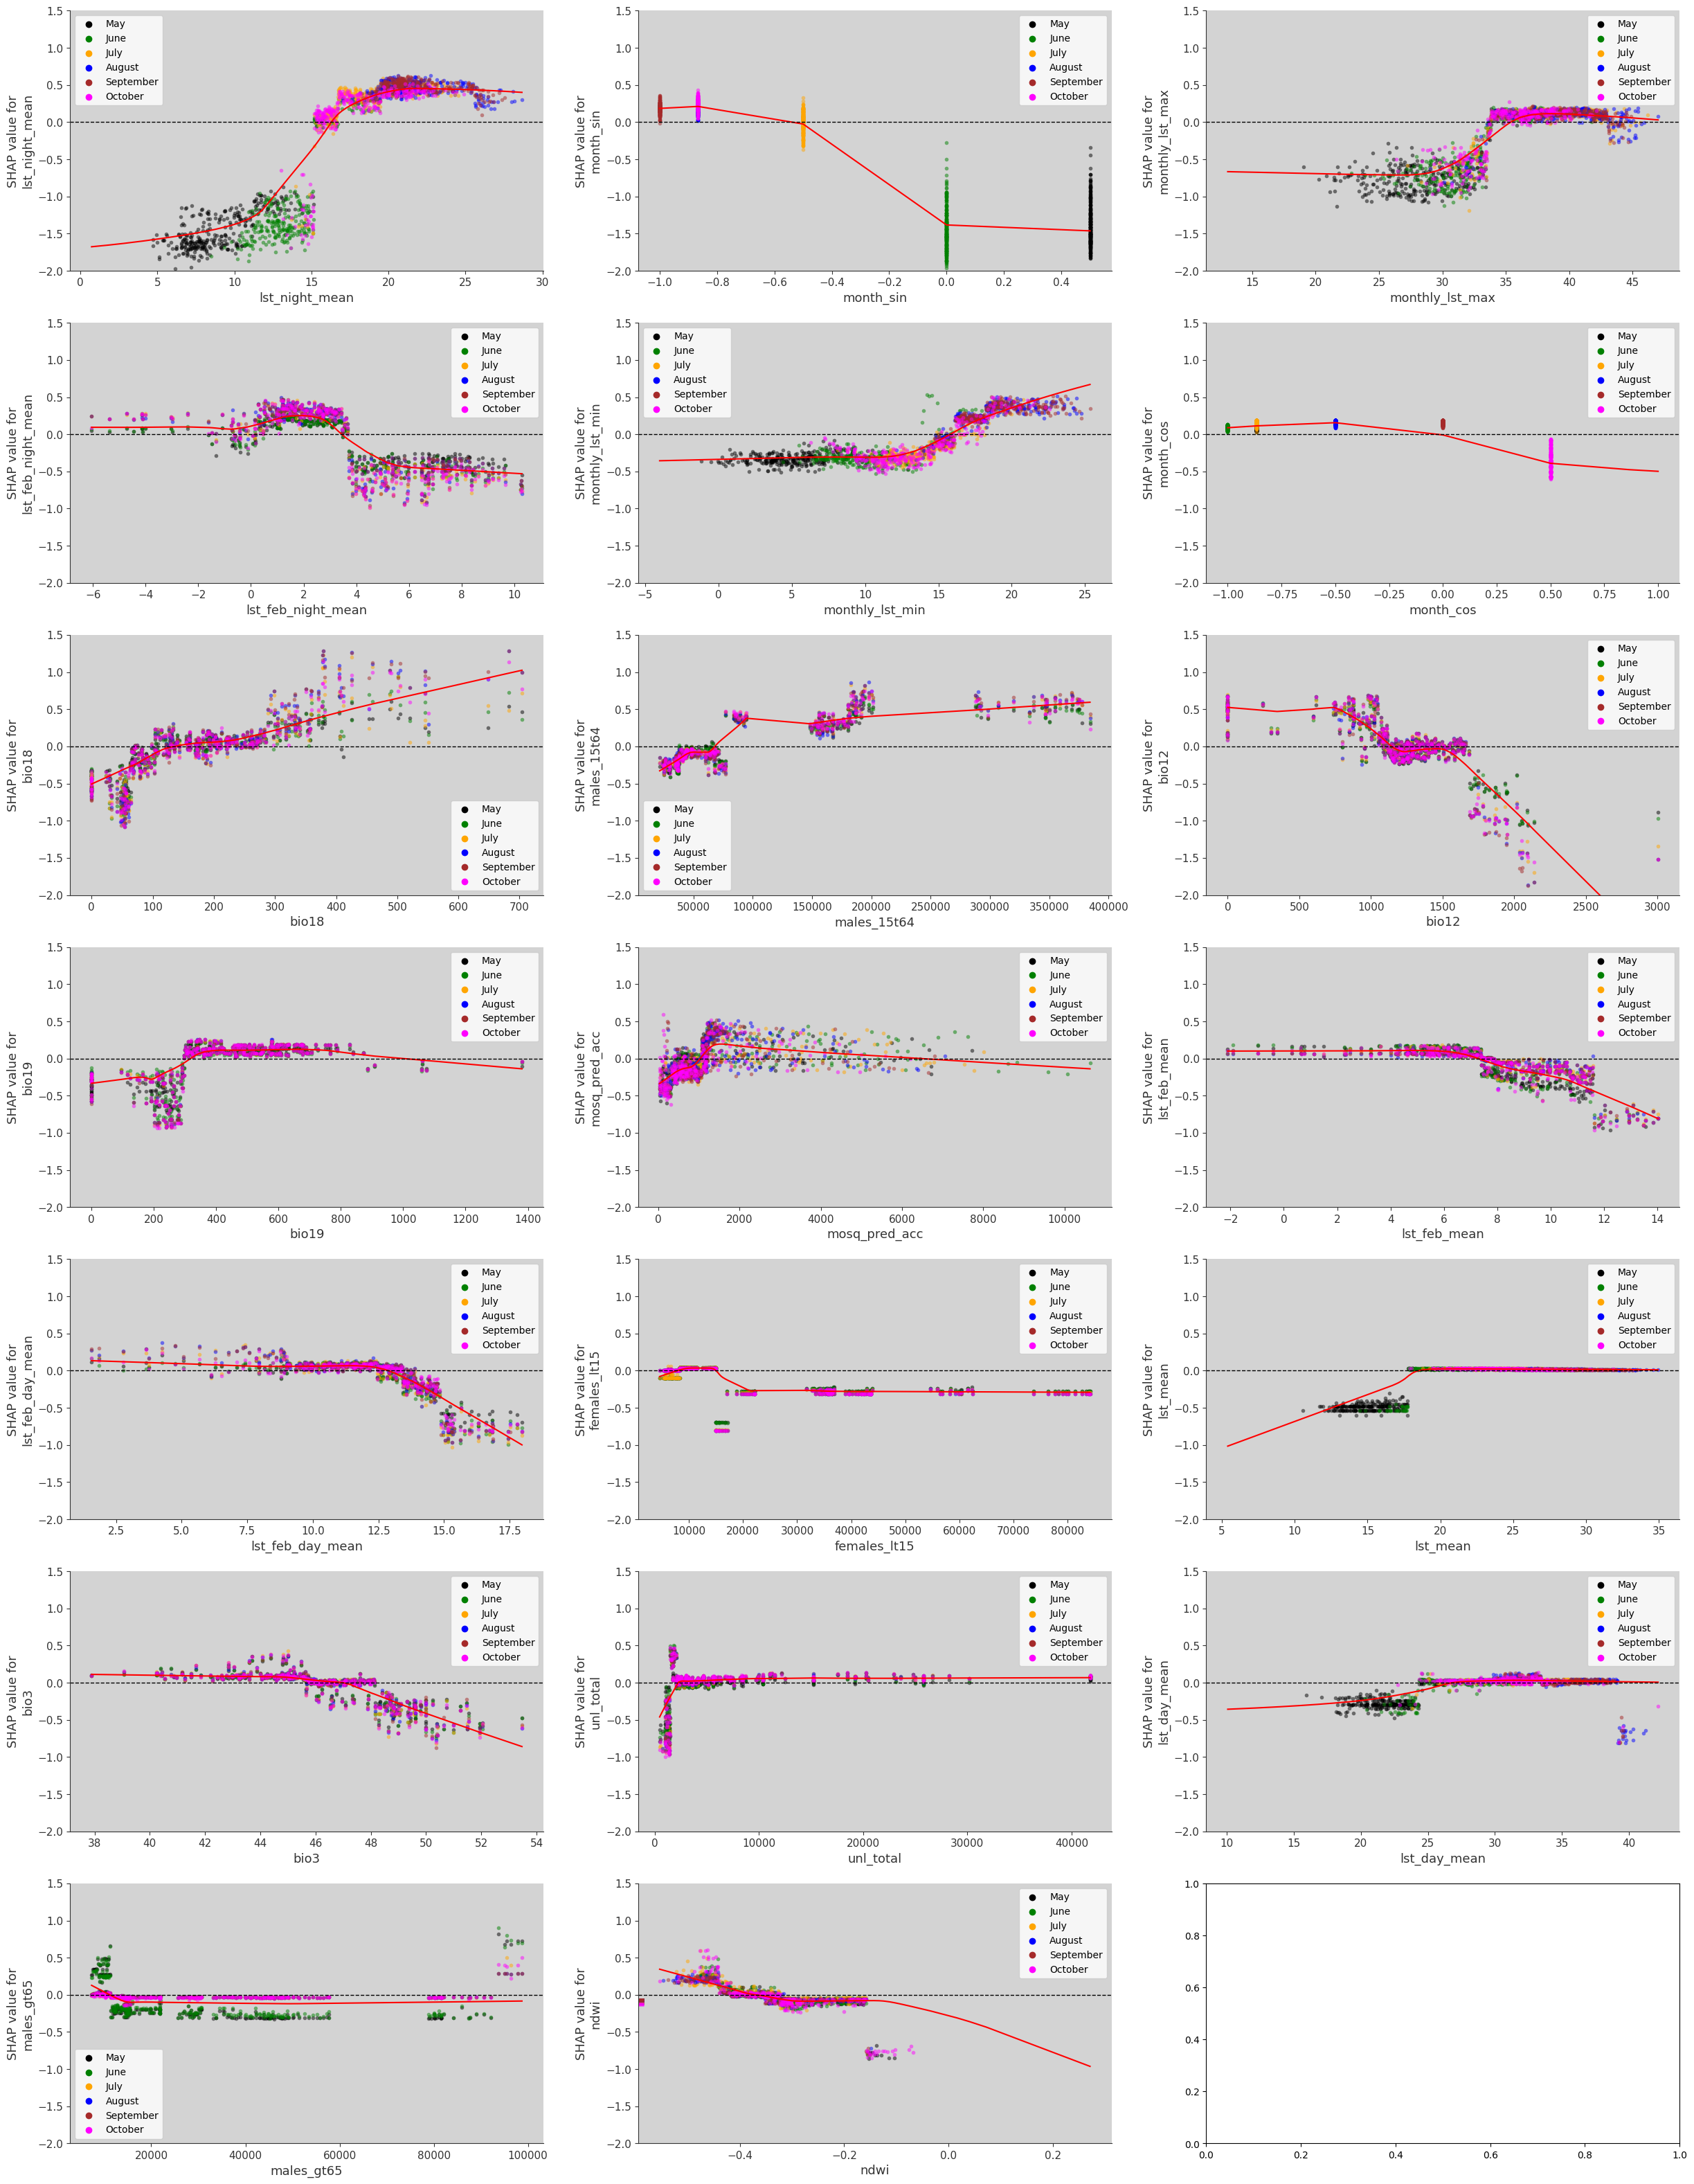

In [41]:
num_plots = 20

fig, axes = plt.subplots(7, 3, figsize=(30, 40))  # Adjust figsize as needed

i = 0

# for ft in ['monthly_lst_min','monthly_lst_max', 'lst_mean', 'lst_day_mean', 'lst_night_mean', 'ndwi']:
for ft in sorted_mean_abs_values_idx[:num_plots]:
    row = i // 3
    col = i % 3
    
    ax = axes[row, col]
    ax.set_facecolor('lightgrey')
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = data.columns

    shap_values_may = shap_values_df_may
    data_may = X_train[month_may]

    shap_values_jun = shap_values_df_jun
    data_jun = X_train[month_jun]

    shap_values_jul = shap_values_df_jul
    data_jul = X_train[month_jul]

    shap_values_aug = shap_values_df_aug
    data_aug = X_train[month_aug]

    shap_values_sep = shap_values_df_sep
    data_sep = X_train[month_sep]

    shap_values_oct = shap_values_df_oct
    data_oct = X_train[month_oct]

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=lowess_it, frac=lowess_frac)
    
    ax.plot(*list(zip(*lowess)), color="red", lw=1.5)
    ax.axhline(y=0, color='black', linestyle='--', lw=1)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind=feature, shap_values=shap_values_may, features=data_may, feature_names=feature_names, interaction_index=None, 
                         color='black', alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='May', color='black')

    shap.dependence_plot(ind=feature, shap_values=shap_values_jun, features=data_jun, feature_names=feature_names, interaction_index=None, 
                         color='green', alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='June', color='green')
    
    shap.dependence_plot(ind=feature, shap_values=shap_values_jul, features=data_jul, feature_names=feature_names, interaction_index=None, 
                         color='orange',  alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='July', color='orange')
    
    shap.dependence_plot(ind=feature, shap_values=shap_values_aug, features=data_aug, feature_names=feature_names, interaction_index=None, 
                         color='blue', alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='August', color='blue')

    shap.dependence_plot(ind=feature, shap_values=shap_values_sep, features=data_sep, feature_names=feature_names, interaction_index=None, 
                         color='brown', alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='September', color='brown')

    shap.dependence_plot(ind=feature, shap_values=shap_values_oct, features=data_oct, feature_names=feature_names, interaction_index=None, 
                         color='fuchsia', alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='October', color='fuchsia')
    
    ax.legend()
    
    i = i+1

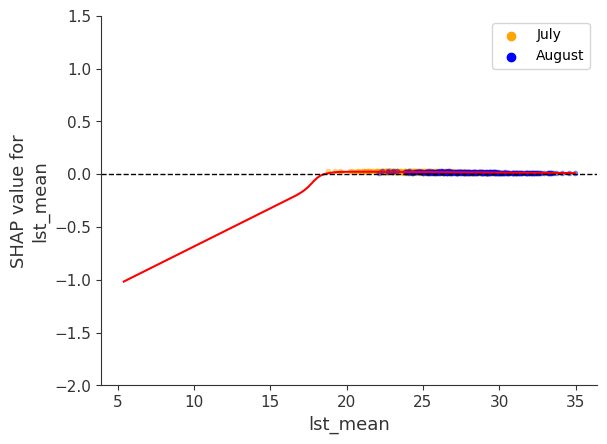

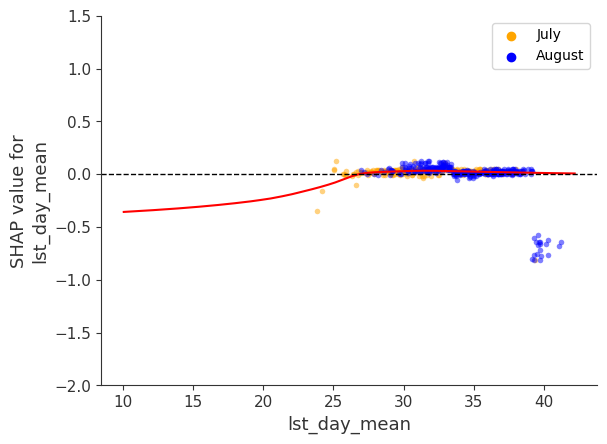

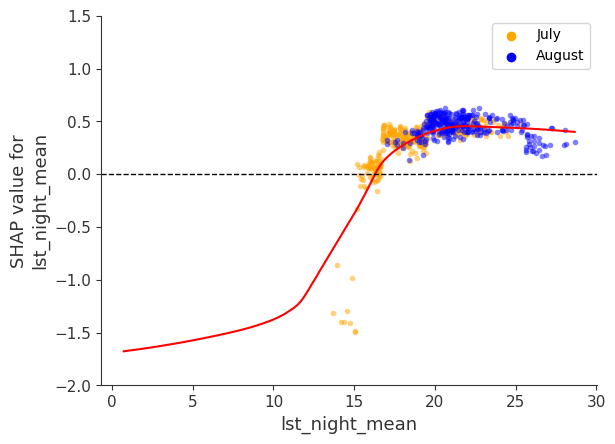

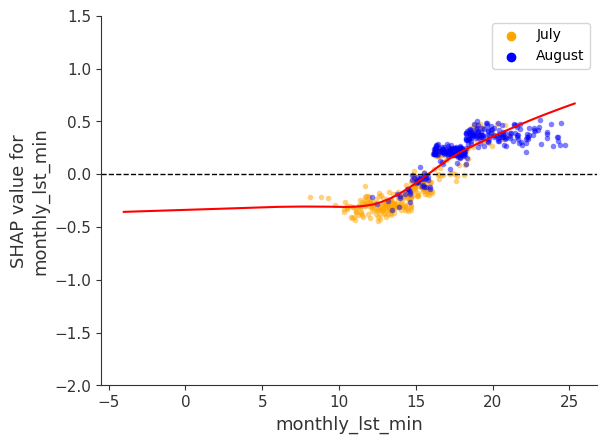

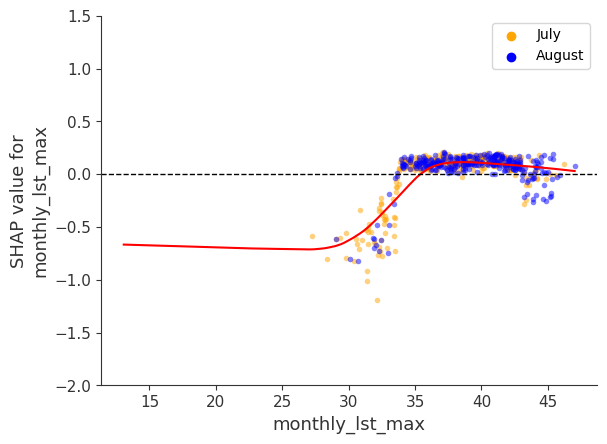

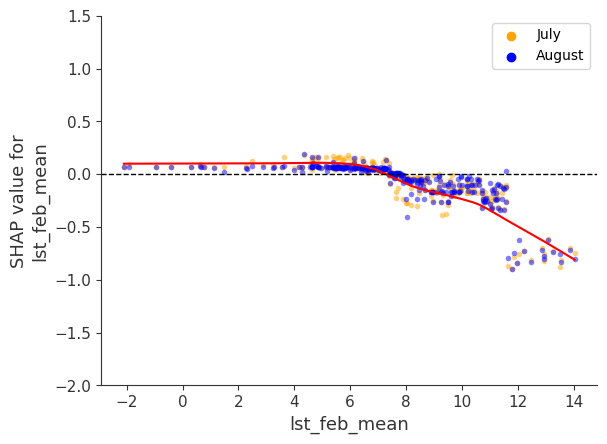

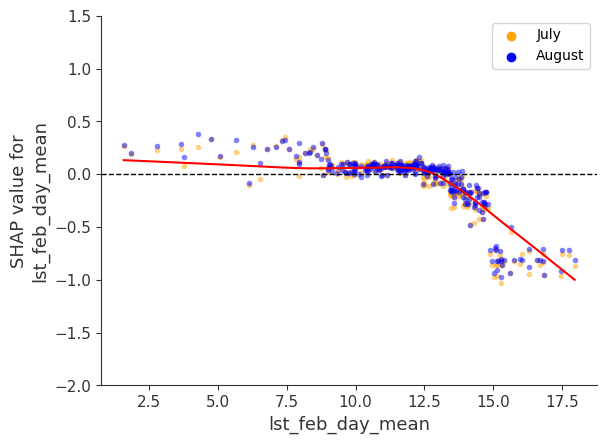

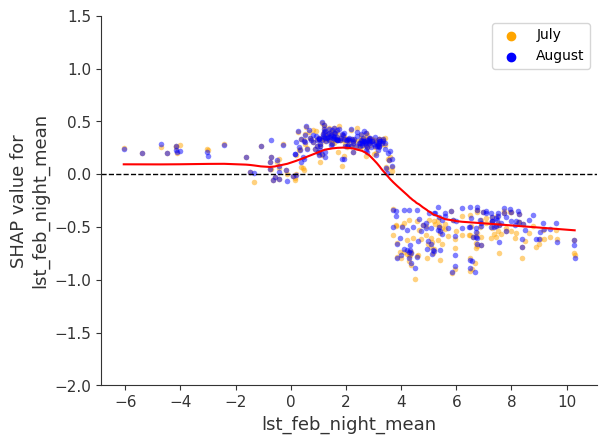

In [44]:
# for ft in ['monthly_lst_min','monthly_lst_max', 'lst_mean', 'lst_day_mean', 'lst_night_mean', 'ndwi', 'bio18', 'bio19', 'bio12', 'bio3']:
# for ft in ['bio18', 'bio19', 'bio12', 'bio3']:
for ft in ['lst_mean', 'lst_day_mean', 'lst_night_mean', 'monthly_lst_min', 'monthly_lst_max', 'lst_feb_mean', 'lst_feb_day_mean', 'lst_feb_night_mean']:
# for ft in sorted_mean_abs_values_idx[:num_plots]:
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = X_train.columns

    shap_values_may = shap_values_df_may
    data_may = X_train[month_may]

    shap_values_jun = shap_values_df_jun
    data_jun = X_train[month_jun]

    shap_values_jul = shap_values_df_jul
    data_jul = X_train[month_jul]

    shap_values_aug = shap_values_df_aug
    data_aug = X_train[month_aug]

    shap_values_sep = shap_values_df_sep
    data_sep = X_train[month_sep]

    shap_values_oct = shap_values_df_oct
    data_oct = X_train[month_oct]

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=lowess_it,frac=lowess_frac)
    _,ax = plt.subplots()
    # ax.set_facecolor('lightgrey')
    ax.plot(*list(zip(*lowess)), color="red", lw = 1.5)
    ax.axhline(y=0, color='black', linestyle='--', lw=1)
    ax.set_ylim(shap_lim)
    
    # shap.dependence_plot(ind=feature, shap_values=shap_values_may, features=data_may, feature_names=feature_names, interaction_index=None, 
    #                      color='black', alpha=shap_alpha, ax=ax, show = False)
    # ax.scatter([], [], label='May', color='black')

    # shap.dependence_plot(ind=feature, shap_values=shap_values_jun, features=data_jun, feature_names=feature_names, interaction_index=None, 
    #                      color='green', alpha=shap_alpha, ax=ax, show = False)
    # ax.scatter([], [], label='June', color='green')
    
    shap.dependence_plot(ind=feature, shap_values=shap_values_jul, features=data_jul, feature_names=feature_names, interaction_index=None, 
                         color='orange',  alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='July', color='orange')
    
    shap.dependence_plot(ind=feature, shap_values=shap_values_aug, features=data_aug, feature_names=feature_names, interaction_index=None, 
                         color='blue', alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='August', color='blue')

    # shap.dependence_plot(ind=feature, shap_values=shap_values_sep, features=data_sep, feature_names=feature_names, interaction_index=None, 
    #                      color='brown', alpha=shap_alpha, ax=ax, show = False)
    # ax.scatter([], [], label='September', color='brown')

    # shap.dependence_plot(ind=feature, shap_values=shap_values_oct, features=data_oct, feature_names=feature_names, interaction_index=None, 
    #                      color='fuchsia', alpha=shap_alpha, ax=ax, show = False)
    # ax.scatter([], [], label='October', color='fuchsia')
    
    ax.legend()

### ------------------------------------ END ------------------------------------ # 